# TP-1 — TinyGPT: pretraining, decodificación y Mixture of Experts

Autor: Msc. Abraham R.

Resolución: Fermín Rodríguez del Castillo — Maestría en Inteligencia Artificial (FIUBA)

Vas a preentrenar un GPT muy pequeño (un decoder transformer) a nivel de caracteres sobre
Shakespeare, y después trabajarlo en dos direcciones.

## Arquitecturas de TinyGPT

Pensado para la [materia NLP-II](https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/CEIA-LLMIAG),
donde tratamos arquitecturas y teoría, vamos a empezar con un modelo denso, equivalente y
basado en GPT-2, para terminar en un modelo que consiste en un **GPT de Mixture of
Experts**, equivalente a modelos como:
- DeepSeek-MoE/v2/v3/R1
- Qwen-MoE
- Mistral/Mixtral

**Parte 1 — Inferencia.** El modelo te da una distribución de probabilidad sobre el
siguiente carácter. *Elegir* un carácter a partir de ella es una decisión de diseño
aparte, y cambia la salida mucho más de lo que lo haría otra época de entrenamiento.

**Parte 2 — Arquitectura.** Reemplazá el bloque feed-forward denso por un Mixture of
Experts, y medí qué te da y qué te cuesta.

Se entrena un solo modelo, una sola vez, al principio, y se reutiliza en todo el trabajo.

## Consignas

**Parte 1**
- Consigna I — implementar `generateV2`: greedy, temperatura, top-k y top-p.
- Consigna II — comparar las estrategias de decodificación y explicar qué hace cada perilla.
- Consigna III — medir qué te da realmente el KV-cache. No asumas que gana.
- Consigna IV — leer e interpretar los mapas de atención de tu modelo entrenado.

**Parte 2**
- Consigna V — implementar ruteo top-k en `MoELayer.forward`.
- Consigna VI — entrenar TinyGPT-MoE y compararlo contra el baseline denso.
- Consigna VII — medir la utilización de expertos y diagnosticar colapso de ruteo.
- Consigna VIII — implementar [DeepSeekMoE](https://arxiv.org/pdf/2401.06066) y medirlo.
- Consigna IX — tu MoE es mucho más lento por paso que el modelo denso. Hacelo más rápido.

**Después**
- Consigna X — preentrenar el modelo *denso* con un tokenizer subword real de GPT-2 y
  comparar como corresponde. El TP-2 y el notebook del TP-3 dependen del checkpoint que
  produce esta consigna.
- *Opcional* — una loss auxiliar de balanceo de carga.

## Cómo trabajar en esto

Toda consigna de la que dependa una celda posterior viene con una celda `check_*()`.
Corréla antes de seguir — cuesta segundos y atrapa los bugs que si no aparecerían como
una curva de loss plana media hora más tarde. Que pasen todos los self-checks es el mínimo
para entregar.



In [1]:
import time
from typing import List, Optional

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader

from tinygpt import (
    CharDataset,
    CharTokenizer,
    GPTConfig,
    MoEArgs,
    count_parameters,
    describe,
    free,
    load_checkpoint,
    get_device,
    load_tinyshakespeare,
    plot_losses,
    resume,
    run_training,
    trim_kv_cache,
    visualize_attention,
)
from trainer import Trainer

torch.manual_seed(1337)

# torch.amp.GradScaler existe recién desde torch 2.3, y el último torch para Mac Intel es 2.2.2.
# trainer.py lo instancia siempre (deshabilitado fuera de CUDA), así que lo mapeamos al de torch.cuda.amp.
if not hasattr(torch.amp, "GradScaler"):
    torch.amp.GradScaler = lambda device=None, **kwargs: torch.cuda.amp.GradScaler(**kwargs)


## Retomar después de reiniciar el kernel

Este notebook entrena cuatro modelos y los mantiene en memoria, así que un reinicio los
pierde a todos y toda celda de acá para abajo falla con `NameError`. Los pesos y las curvas
de loss están en disco, así que no hace falta reentrenar — corré la celda de abajo y saltá
hasta donde estabas.

En una corrida desde cero no la toques: sólo restaura lo que ya está terminado.


In [2]:
def resume_all():
    """
    Reconstruye los modelos que ya tengan un checkpoint terminado.

    Corré primero las celdas de arriba -- las definiciones son instantáneas, lo único que no
    lo es es el entrenamiento -- y después llamá a esto. Restaura cada modelo y su curva de
    loss, y saltea todo aquello cuya clase o config todavía no esté en memoria.
    """
    import os

    g = globals()
    specs = [
        ("model",     "./checkpoints/tp1_dense",    "history",     ("config",)),
        ("moe_model", "./checkpoints/tp1_moe",      "history_moe", ("moe_config",)),
        ("ds_model",  "./checkpoints/tp1_deepseek", "history_ds",  ("ds_config",)),
        ("sub_model", "./checkpoints/tp1_subword",  "sub_history", ("sub_config",)),
    ]

    made, skipped = [], []
    for name, path, hist, needs in specs:
        if not os.path.exists(os.path.join(path, "checkpoint_final.pt")):
            continue
        if any(n not in g for n in needs):
            skipped.append(f"{name} (necesita {', '.join(needs)})")
            continue
        # reutiliza el objeto si la celda de config ya construyó uno sin entrenar
        m = g.get(name) or g["TinyGPT"](g[needs[0]]).to(g["device"])
        g[name], g[hist] = m, g["resume"](m, path, map_location=g["device"])
        made.append(name)

    print("restaurados:", ", ".join(made) if made else "nada")
    if skipped:
        print("todavía no:", "; ".join(skipped))


# resume_all()   # descomentar después de reiniciar el kernel


## Descarga del dataset

In [3]:
# Bajá esto si el entrenamiento es lento en tu máquina.
N_CHARS = 100_000

text = load_tinyshakespeare(N_CHARS)
print(text[:400])
print(f"...\n\n{len(text):,} caracteres")

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it 
...

100,000 caracteres


## Codificación a nivel de caracteres

`CharTokenizer` mapea cada carácter distinto a un id entero. Un carácter == un token.

In [4]:
tokenizer = CharTokenizer(text)
print(f"vocab_size = {tokenizer.vocab_size}")
print(repr("".join(tokenizer.chars)))

data = torch.tensor(tokenizer.encode(text), dtype=torch.long)

# Split de entrenamiento/validación
split = int(0.9 * len(data))
train_data, val_data = data[:split], data[split:]
print(f"entrenamiento {train_data.shape} | validación {val_data.shape}")

vocab_size = 61
"\n !&',-.:;?ABCDEFGHIJKLMNOPQRSTUVWYabcdefghijklmnopqrstuvwxyz"
entrenamiento torch.Size([90000]) | validación torch.Size([10000])


## Configuración del GPT

`ff_class` le permite a la Parte 2 cambiar el bloque feed-forward por un MoE sin tocar el
código del modelo.

In [5]:
config = GPTConfig(vocab_size=tokenizer.vocab_size)
print(config)

GPTConfig(block_size=32, batch_size=64, n_embd=64, n_head=4, n_layer=2, dropout=0.1, vocab_size=61, bias=True, tie_weights=True, ff_class=None, moe_args=None)


## Dataloaders

In [6]:
# Usá 0 en macOS/MPS; unos pocos workers ayudan en CUDA.
NUM_WORKERS = 0

train_dataset = CharDataset(train_data, config.block_size)
val_dataset = CharDataset(val_data, config.block_size)

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True,
                          drop_last=True, pin_memory=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False,
                        drop_last=True, pin_memory=True, num_workers=NUM_WORKERS)

print(f"{len(train_loader)} batches de entrenamiento | {len(val_loader)} de validación")

1405 batches de entrenamiento | 155 de validación


# La arquitectura

Las próximas tres celdas son todo el modelo. *Leelas antes de correrlas*. El resto de la
materia se apoya en este código, y el TP-2 lo importa desde `tinygpt.py` en vez de
redefinirlo.

Hay tres detalles que merecen tu atención, porque son los más fáciles de tener mal en
silencio:

1. Todo `forward` devuelve la misma 3-tupla `(out, kv_cache, weights)`. Decidir la forma
   del retorno según *si te pasaron un cache o no* es un bug clásico: el primer paso de
   decodificación no tiene cache para pasar, así que el cache nunca se activa y
   `use_cache=True` queda en un no-op del que nunca te enterás.
2. La máscara causal y los positional embeddings están ambos desplazados por el largo del
   cache. Con cache el modelo ve un token nuevo, pero ese token no está en la posición 0.
3. Todas las cabezas se proyectan y atienden en un único matmul batcheado, no en un loop
   de Python sobre módulos por cabeza. A esta escala el tiempo de reloj está dominado por
   los lanzamientos de kernel más que por la aritmética, así que un loop sobre `n_head`
   módulos cuesta varias veces el resto del paso — que es el mismo efecto que vas a medir,
   y arreglar, en la Consigna IX.

In [7]:
class MultiHeadAttention(nn.Module):
    """
    Self-atención causal multi-cabeza, batcheada a lo largo de las cabezas.

    Todas las cabezas se proyectan en un solo matmul y atienden en un solo matmul
    batcheado, en vez de iterar sobre un módulo `AttentionHead` por cabeza. La versión con
    loop es más fácil de leer pero lanza `n_head` kernels chicos por capa, y a este tamaño
    de modelo el tiempo de reloj está dominado por los lanzamientos de kernel más que por
    la aritmética -- así que el loop costaba varias veces todo el resto del paso.

    La atención sigue escrita a mano (scores, máscara causal, softmax) en vez de llamar a
    F.scaled_dot_product_attention, porque la máscara es justamente lo que se está
    enseñando y SDPA no puede devolver los pesos de atención para la consigna de
    visualización.

    Todo forward devuelve la misma 3-tupla `(out, kv_cache, weights)`; las entradas
    finales son `None` cuando no se piden.
    """

    def __init__(self, args: GPTConfig):
        super().__init__()
        assert args.n_embd % args.n_head == 0, "n_embd tiene que ser divisible por n_head"
        self.n_head = args.n_head
        self.head_dim = args.n_embd // args.n_head

        # Una sola proyección para todas las cabezas: (B, T, C) -> (B, T, 3C), partida en K, Q, V.
        self.key_query_value = nn.Linear(args.n_embd, 3 * args.n_embd, bias=args.bias)
        self.proj = nn.Linear(args.n_embd, args.n_embd, bias=args.bias)

        self.attn_dropout = nn.Dropout(args.dropout)
        self.dropout = nn.Dropout(args.dropout)
        self.register_buffer(
            "tril", torch.tril(torch.ones(args.block_size, args.block_size))
        )

    def _split(self, t, B, T):
        """(B, T, C) -> (B, n_head, T, head_dim)"""
        return t.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

    def forward(self, x, kv_cache=None, use_cache=False, return_weights=False):
        B, T, C = x.shape
        k, q, v = self.key_query_value(x).chunk(3, dim=-1)
        k, q, v = self._split(k, B, T), self._split(q, B, T), self._split(v, B, T)

        if kv_cache is not None:
            k_prev, v_prev = kv_cache.unbind(dim=0)      # (B, n_head, T_past, head_dim)
            k = torch.cat((k_prev, k), dim=2)
            v = torch.cat((v_prev, v), dim=2)

        new_cache = torch.stack((k, v)) if use_cache else None

        T_k = k.size(2)          # total de keys atendidas
        past = T_k - T           # cuántas de ellas vinieron del cache

        wei = q @ k.transpose(-2, -1) * (self.head_dim ** -0.5)   # (B, n_head, T, T_k)
        # Las filas están desplazadas por `past` para que la máscara siga siendo correcta
        # con KV-cache: la query en la posición absoluta `past + t` puede ver las keys
        # 0..past + t.
        wei = wei.masked_fill(self.tril[past:T_k, :T_k] == 0, float("-inf"))
        wei = F.softmax(wei, dim=-1)
        wei = self.attn_dropout(wei)

        out = (wei @ v).transpose(1, 2).contiguous().view(B, T, C)
        out = self.dropout(self.proj(out))

        # (n_head, B, T, T_k) -- el layout que espera visualize_attention
        weights = wei.transpose(0, 1) if return_weights else None
        return out, new_cache, weights

In [8]:
class FeedForward(nn.Module):
    """MLP densa: el módulo que la Parte 2 reemplaza por un MoE."""

    def __init__(self, config: GPTConfig):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, 4 * config.n_embd),
            nn.ReLU(),
            nn.Linear(4 * config.n_embd, config.n_embd),
            nn.Dropout(config.dropout),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    """Bloque decoder transformer pre-norm."""

    def __init__(self, config: GPTConfig):
        super().__init__()
        self.ln1 = nn.LayerNorm(config.n_embd)
        self.ln2 = nn.LayerNorm(config.n_embd)
        self.attn = MultiHeadAttention(config)

        ff_class = config.ff_class if config.ff_class is not None else FeedForward
        self.ff = ff_class(config)

    def forward(self, x, kv_cache=None, use_cache=False, return_weights=False):
        attn_out, new_cache, weights = self.attn(
            self.ln1(x), kv_cache=kv_cache, use_cache=use_cache, return_weights=return_weights
        )
        x = x + attn_out
        x = x + self.ff(self.ln2(x))
        return x, new_cache, weights

## TinyGPT

In [9]:
class TinyGPT(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.config = config
        self.token_emb = nn.Embedding(config.vocab_size, config.n_embd)
        self.pos_emb = nn.Embedding(config.block_size, config.n_embd)
        self.blocks = nn.ModuleList([Block(config) for _ in range(config.n_layer)])
        self.ln_f = nn.LayerNorm(config.n_embd)
        self.head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        if config.tie_weights:
            self.head.weight = self.token_emb.weight

    def forward(self, idx, kv_cache=None, use_cache=False, return_weights=False):
        """
        Args:
            idx:            ids de tokens (B, T).
            kv_cache:       lista de caches por capa de una llamada anterior, o None.
            use_cache:      devolver un KV-cache actualizado junto con los logits.
            return_weights: devolver los mapas de atención por capa junto con los logits.

        Returns:
            `logits` cuando ambos flags son False (esto es lo que espera `Trainer`),
            si no, una tupla `(logits[, kv_cache][, attn_weights])`.

        Notá que los flags determinan la forma del retorno -- NO el hecho de que
        `kv_cache` sea None o no. Derivarla de la entrada es la manera en que un
        cache nunca se activa en silencio: el primer paso de decodificación no
        tiene cache para pasar.
        """
        B, T = idx.shape
        past_len = kv_cache[0].shape[-2] if kv_cache is not None else 0
        assert past_len + T <= self.config.block_size, (
            f"la secuencia de {past_len + T} excede block_size={self.config.block_size}"
        )

        tok_emb = self.token_emb(idx)
        # Las posiciones tienen que continuar desde donde quedó el cache; si no, cada
        # paso cacheado reutiliza la posición 0.
        pos = torch.arange(past_len, past_len + T, device=idx.device)
        x = tok_emb + self.pos_emb(pos)[None, :, :]

        new_kv_cache = [] if use_cache else None
        all_weights = [] if return_weights else None

        for i, block in enumerate(self.blocks):
            layer_cache = kv_cache[i] if kv_cache is not None else None
            x, updated_kv, weights = block(
                x, kv_cache=layer_cache, use_cache=use_cache, return_weights=return_weights
            )
            if use_cache:
                new_kv_cache.append(updated_kv)
            if return_weights:
                all_weights.append(weights)

        logits = self.head(self.ln_f(x))

        if not use_cache and not return_weights:
            return logits
        out = [logits]
        if use_cache:
            out.append(new_kv_cache)
        if return_weights:
            out.append(all_weights)
        return tuple(out)

    @torch.no_grad()
    def resize_token_embeddings(self, new_vocab_size: int) -> None:
        """
        Agranda el embedding de entrada y la cabeza de salida hasta `new_vocab_size`,
        preservando todas las filas preentrenadas.

        Hace falta cuando el fine-tuning agrega tokens especiales (marcadores de
        chat/instrucciones) que el vocabulario de preentrenamiento no tenía.
        """
        old_vocab, n_embd = self.token_emb.weight.shape
        if new_vocab_size == old_vocab:
            return
        assert new_vocab_size > old_vocab, "achicar el vocabulario no está soportado"

        device = self.token_emb.weight.device
        dtype = self.token_emb.weight.dtype

        new_emb = nn.Embedding(new_vocab_size, n_embd, device=device, dtype=dtype)
        new_emb.weight.normal_(mean=0.0, std=0.02)
        new_emb.weight[:old_vocab] = self.token_emb.weight
        self.token_emb = new_emb

        new_head = nn.Linear(n_embd, new_vocab_size, bias=False, device=device, dtype=dtype)
        new_head.weight.normal_(mean=0.0, std=0.02)
        new_head.weight[:old_vocab] = self.head.weight
        self.head = new_head

        self.config.vocab_size = new_vocab_size

## Generación baseline (inferencia)

Esta es la función que vas a mejorar en la Consigna I. Muestrea del softmax *completo* a
temperatura 1.0 — sin truncamiento, sin control de temperatura.

In [10]:
@torch.no_grad()
def generate(
    model: nn.Module,
    tokenizer: CharTokenizer,
    prompt: str,
    max_new_tokens: int = 100,
    use_cache: bool = True,
    device: Optional[str] = None,
) -> str:
    """
    Decodificación baseline: muestrear del softmax completo a temperatura 1.0.

    Esta es la función que el TP-1 te pide mejorar con greedy / temperatura /
    top-k / top-p.
    """
    model.eval()
    device = device or next(model.parameters()).device
    block_size = model.config.block_size

    idx = torch.tensor(tokenizer.encode(prompt), dtype=torch.long, device=device)[None, :]
    kv_cache = None

    for _ in range(max_new_tokens):
        if kv_cache is None:
            idx_cond = idx[:, -block_size:]
        else:
            idx_cond = idx[:, -1:]

        out = model(idx_cond, kv_cache=kv_cache, use_cache=use_cache)
        if use_cache:
            logits, kv_cache = out
            # Nunca dejes que el cache crezca más que la ventana de contexto.
            kv_cache = trim_kv_cache(kv_cache, block_size - 1)
        else:
            logits = out

        probs = F.softmax(logits[:, -1, :], dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, next_token), dim=1)

    return tokenizer.decode(idx[0].tolist())

# Setup

In [11]:
device = get_device()
print(f"dispositivo: {device}")

model = TinyGPT(config).to(device)
describe(model, "TinyGPT (denso)")

# torch.compile tracea el modelo y fusiona kernels. Es una mejora real en CUDA, es poco
# confiable en MPS (crashea), y da poco a este tamaño de modelo -- así que se habilita
# sólo donde ayuda.
#
# Ojo con lo que le hace a los checkpoints: compilar envuelve al módulo, así que toda
# clave del state-dict gana un prefijo "_orig_mod.". Por eso el TP-2 y el notebook de
# serving cargan los pesos vía tinygpt.load_checkpoint, que lo saca.
if device == "cuda":
    model = torch.compile(model)
    print("torch.compile habilitado")


dispositivo: cpu
TinyGPT (denso): 106,048 parameters | 106,048 trainable (100.00%)


In [12]:
EPOCHS = 2


def make_optimizer(params, lr: float = 1e-3):
    """
    Adam de 8 bits en CUDA, el AdamW de torch en todo lo demás.

    bitsandbytes mantiene el estado del optimizador en 8 bits en vez de 32, lo que reduce
    aproximadamente a la mitad la memoria que necesita Adam -- irrelevante con 800k
    parámetros, y la razón por la que podés hacer fine-tuning de un modelo de 7B en una
    sola GPU.

    Todas las corridas de este notebook lo usan, así que la comparación denso/MoE nunca
    cambia dos cosas a la vez.
    """
    if device == "cuda":
        try:
            from bitsandbytes.optim import AdamW as bnbAdamW
            return bnbAdamW(params, lr=lr)
        except ImportError:
            print("bitsandbytes no está instalado (pip install bitsandbytes) -- se usa el AdamW de torch")
    return AdamW(params, lr=lr)


optimizer = make_optimizer(model.parameters())
scheduler = StepLR(optimizer, step_size=100, gamma=0.9)
loss_fn = torch.nn.CrossEntropyLoss()


/Users/fermin/Desktop/UBA/PLNII/tps-plnii/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[transformers] Disabling PyTorch because PyTorch >= 2.5 is required but found 2.2.2


[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


# Entrenamiento

Aproximadamente un minuto por época en GPU, más en CPU. Bajá `N_CHARS` arriba si necesitás
que sea más rápido.

## Qué corre distinto en CUDA

Hay tres optimizaciones que se habilitan automáticamente cuando hay un dispositivo CUDA
presente, y se saltean si no. Ninguna cambia la matemática — cambian lo que el hardware
hace con ella.

| | qué hace | por qué es sólo para CUDA |
|---|---|---|
| **Adam de 8 bits** (`make_optimizer`) | estado del optimizador en 8 bits en vez de 32, lo que reduce a la mitad la memoria de Adam | `bitsandbytes` no tiene build para Apple Silicon |
| **`torch.compile`** | tracea el modelo y fusiona kernels | poco confiable en MPS; crashea |
| **autocast en bfloat16** (`run_training`) | la mitad de memoria de activaciones, matmuls más rápidos en tensor cores | el autocast de MPS está incompleto y `GradScaler` no soporta ese backend |

A este tamaño de modelo ninguna importa demasiado. Importan enormemente a la escala en la
que realmente las usarías, y por eso están acá en vez de omitidas: Adam de 8 bits es la
diferencia entre poder hacer fine-tuning de un modelo de 7B en una sola GPU y no poder.

`run_training(..., use_amp=True)` fuerza precisión mixta si querés ver qué hace en tu
hardware.

## Una nota sobre memoria

Este notebook entrena cuatro modelos en un mismo kernel y los mantiene vivos, porque las
celdas posteriores los comparan. Ni CUDA ni MPS devuelven al sistema operativo los bloques
liberados por su cuenta, y los gathers de forma variable del MoE fragmentan feo el
allocator — así que sin ayuda el kernel crece hasta que la máquina empieza a hacer swap.

`free()` libera el cache; `run_training` la llama después de cada corrida, y las celdas de
abajo la vuelven a llamar después de soltar un trainer. Si aun así te quedás sin memoria,
reiniciá el kernel y bajá `N_CHARS`.


mixed precision: off


  0%|          | 0/1405 [00:00<?, ?it/s]

  0%|          | 3/1405 [00:00<00:53, 26.27it/s]

  0%|          | 7/1405 [00:00<00:41, 33.42it/s]

loss 32.25330:   0%|          | 7/1405 [00:00<00:41, 33.42it/s]

...

val_loss 1.72668:  95%|█████████▍| 147/155 [00:01<00:00, 110.79it/s]

val_loss 1.59188:  95%|█████████▍| 147/155 [00:01<00:00, 110.79it/s]

val_loss 2.20415:  95%|█████████▍| 147/155 [00:01<00:00, 110.79it/s]

val_loss 2.20415: 100%|██████████| 155/155 [00:01<00:00, 120.51it/s]

epoch 2/2 | train 2.0904 | val 1.9776


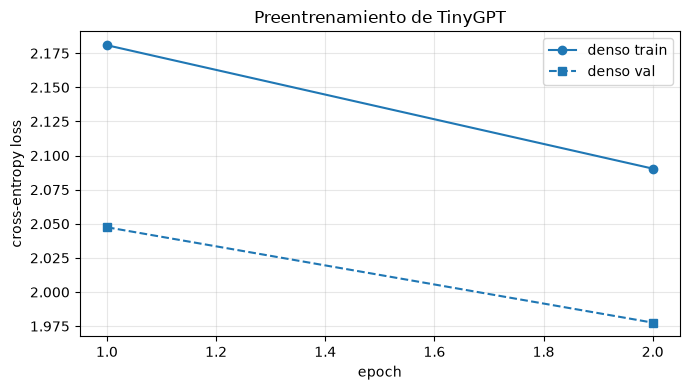

In [13]:
trainer = Trainer(
    model=model,
    train_data_loader=train_loader,
    test_data_loader=val_loader,
    loss_fn=loss_fn,
    gradient_accumulation_steps=1,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    save_dir="./checkpoints/tp1_dense",
    save_every_n=500,
)

history = run_training(trainer, epochs=EPOCHS)
plot_losses({"denso": history}, title="Preentrenamiento de TinyGPT")

# El trainer retiene el estado del optimizador; el modelo en sí todavía hace falta.
del trainer
free()

### Prueba rápida

In [14]:
print(generate(model, tokenizer, "To be", max_new_tokens=300, use_cache=True))

To behe pwel o's Care purot.

MENINIRIRGILINIUSINICINININIUSININIUS:
ANENENINENIAUTIUS:
Thicofashemave tourele uswey, whar re ththustherchis, inerusutitomos t,
lomodered tovelono s fusune'dyow thede want ftrutr: smandidissitathe anthade ulofitovendint tritwfus it, rtise de deanyotutulonthetes us f l 'ove


# Consigna I — estrategias de decodificación

El modelo te da una distribución de probabilidad sobre el siguiente carácter. *Elegir* un
carácter de esa distribución es una decisión de diseño aparte, y cambia la salida mucho más
de lo que lo haría otra época de entrenamiento.

Implementá `generateV2` abajo, soportando:

- Decodificación greedy (elegir el token de máxima probabilidad).
- Muestreo con temperatura.
- Muestreo top-k o top-p.

Aplicá primero la temperatura, después top-k, después top-p, y recién ahí renormalizá y
muestreá. `top_k=None` y `top_p=None` significan sin truncamiento, y `do_sample=False`
ignora todas las demás perillas.

### Referencias
- [huggingface generate](https://huggingface.co/docs/transformers/main_classes/text_generation)
- [The Curious Case of Neural Text Degeneration (top-p)](https://arxiv.org/abs/1904.09751)


In [15]:
@torch.no_grad()
def generateV2(
    model: nn.Module,
    tokenizer: CharTokenizer,
    prompt: str,
    max_new_tokens: int = 300,
    use_cache: bool = True,
    do_sample: bool = True,
    temperature: float = 1.0,
    top_k: Optional[int] = None,
    top_p: Optional[float] = None,
    device: Optional[str] = None,
) -> str:
    """
    Args:
        do_sample:   False -> greedy (arg-max); se ignoran todas las demas perillas.
        temperature: >0. Mas bajo es mas determinista, mas alto es mas aleatorio.
        top_k:       conservar los k tokens mas probables, o None para no truncar.
        top_p:       conservar el conjunto mas chico cuya probabilidad acumulada sea >= p,
                     o None para no truncar.

    Returns:
        El prompt mas `max_new_tokens` caracteres generados.
    """
    model.eval()
    device = device or next(model.parameters()).device
    block_size = model.config.block_size

    idx = torch.tensor(tokenizer.encode(prompt), dtype=torch.long, device=device)[None, :]
    kv_cache = None

    for _ in range(max_new_tokens):
        # --- Andamiaje identico al baseline `generate`: ventana de contexto + KV-cache ---
        if kv_cache is None:
            idx_cond = idx[:, -block_size:]
        else:
            idx_cond = idx[:, -1:]

        out = model(idx_cond, kv_cache=kv_cache, use_cache=use_cache)
        if use_cache:
            logits, kv_cache = out
            kv_cache = trim_kv_cache(kv_cache, block_size - 1)
        else:
            logits = out

        logits = logits[:, -1, :]   # (B, vocab) -> logits del proximo token

        # --- Consigna I: elegir el token de esta distribucion ---

        # 0) Greedy: arg-max, sin muestreo. Ignora temperatura / top-k / top-p.
        if not do_sample:
            next_token = torch.argmax(logits, dim=-1, keepdim=True)
            idx = torch.cat((idx, next_token), dim=1)
            continue

        # 1) Temperatura: escala los logits ANTES del softmax.
        #    T<1 agudiza (mas determinista), T>1 aplana (mas aleatorio).
        #    T->0 hace que el arg-max domine => se acerca a greedy (self-check 3).
        logits = logits / max(temperature, 1e-8)

        # 2) Top-k: quedarse con los k logits mas altos, el resto a -inf.
        #    k=1 deja solo el arg-max => equivale a greedy (self-check 2).
        if top_k is not None:
            k = min(top_k, logits.size(-1))
            kth_vals = torch.topk(logits, k, dim=-1).values[..., -1, None]  # k-esimo mayor
            logits = logits.masked_fill(logits < kth_vals, float("-inf"))

        # 3) Top-p (nucleus): conservar el conjunto MAS CHICO cuya prob. acumulada >= p.
        #    Clave (self-check 4): el token que CRUZA el umbral se incluye siempre, asi
        #    que con p->0 queda exactamente 1 token (el mas probable), nunca 0.
        if top_p is not None:
            sorted_logits, sorted_idx = torch.sort(logits, descending=True, dim=-1)
            probs_sorted = F.softmax(sorted_logits, dim=-1)
            cumprobs = probs_sorted.cumsum(dim=-1)
            # Descartamos los que YA superaron p; el shift a la derecha garantiza que el
            # primer token que cruza el umbral (y al menos ese) quede dentro del nucleo.
            remove_sorted = cumprobs > top_p
            remove_sorted[..., 1:] = remove_sorted[..., :-1].clone()
            remove_sorted[..., 0] = False
            # Volvemos al orden original del vocabulario para aplicar la mascara.
            remove = torch.zeros_like(remove_sorted).scatter(-1, sorted_idx, remove_sorted)
            logits = logits.masked_fill(remove, float("-inf"))

        # 4) Renormalizar sobre lo que sobrevivio y muestrear.
        probs = F.softmax(logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, next_token), dim=1)

    return tokenizer.decode(idx[0].tolist())


## Self-check

Tres propiedades que tienen que cumplirse si tu implementación está bien. Corré esto antes
de seguir — atrapa la mayoría de los bugs.

In [16]:
def self_check():
    kw = dict(model=model, tokenizer=tokenizer, prompt="To be")

    # 1. greedy es determinista
    a = generateV2(**kw, max_new_tokens=60, do_sample=False)
    b = generateV2(**kw, max_new_tokens=60, do_sample=False)
    assert a == b, "la decodificación greedy no es determinista"

    # 2. top_k=1 colapsa la distribución sobre el arg-max, así que tiene que dar igual que greedy
    torch.manual_seed(0)
    c = generateV2(**kw, max_new_tokens=60, do_sample=True, top_k=1)
    assert c == a, "top_k=1 debería reducirse a greedy"

    # Los dos siguientes miran un solo paso: a lo largo de muchos pasos, un casi-empate
    # entre los dos logits más altos termina rompiendo la igualdad exacta, lo que no
    # prueba nada.
    one = generateV2(**kw, max_new_tokens=1, do_sample=False)

    # 3. temperatura -> 0 vuelve al softmax one-hot en el arg-max
    torch.manual_seed(0)
    assert generateV2(**kw, max_new_tokens=1, do_sample=True, temperature=1e-3) == one, \
        "temperatura -> 0 debería acercarse a greedy"

    # 4. top_p -> 0 tiene que dejar exactamente un token: el más probable. Este es el
    #    off-by-one de las pistas -- una comparación mal puesta deja el conjunto vacío acá.
    torch.manual_seed(0)
    assert generateV2(**kw, max_new_tokens=1, do_sample=True, top_p=1e-9) == one, \
        "top_p -> 0 debería dejar únicamente el token más probable"

    print("todos los checks pasaron")


self_check()

todos los checks pasaron


# Consigna II — comparar las estrategias

Corré la grilla de abajo, leé las muestras, y contestá las preguntas que siguen.

In [17]:
PROMPT = "To be"

SETTINGS = [
    ("greedy",              dict(do_sample=False)),
    ("muestreo puro (T=1)", dict(do_sample=True)),
    ("T=0.5",               dict(do_sample=True, temperature=0.5)),
    ("T=1.5",               dict(do_sample=True, temperature=1.5)),
    ("top_k=10",            dict(do_sample=True, top_k=10)),
    ("top_p=0.9",           dict(do_sample=True, top_p=0.9)),
    ("T=0.8 + top_p=0.9",   dict(do_sample=True, temperature=0.8, top_p=0.9)),
]

for name, kwargs in SETTINGS:
    torch.manual_seed(0)
    out = generateV2(model, tokenizer, PROMPT, max_new_tokens=200, **kwargs)
    print("=" * 70)
    print(f"### {name}")
    print(out)

### greedy
To be the the the the the the theateateateateateatererereno the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the t


### muestreo puro (T=1)
To bentit watay earm,
BRUTUS:
ENollll n:
I ser blis I n s t ICounicheeSofinellaryonothithume xu an dendyus momun bthy besusut vot akeisut thembe

Deputunay rdeatofis!  theteusthes, yole imemy  he wantowill


### T=0.5
To be the warthe and hom the your t n n d aser bllld t se t st thicoustounde the touthe husthoust t thouf t thendothe sthe the the he sutithe sthe pe thenovedeathe the there sthest your tosthe the thenathe


### T=1.5
To beveperwaus hearm,
BRUTUS: my t?
n n:
brseobrigheI n s t okgonucheeSlendellaryoecI I hummaxu an venopus momun othyt tuuslam? t akkisutithembe

DIputunayvrdiatofis!n theteus:ins, y'le im, yy heby'denathr


### top_k=10
To bentit wat your maing arn yourt wn n dirserndighes n s t st tusotherofinellaryoncone hure mu an denours momun bthy besusut wot akethit thembele de
tunaverdeatofo wusthetens stongrole imety bus wantowill


### top_p=0.9
To bentit watay mand worthin yourt wn n d aser blises n s t st toucheerofinellaryoncone hure ou an dend f ded
Indothyobesusut idstakeisut the be

upe tunavardeatofis w thetensthes, yole imyoly he wantouthe


### T=0.8 + top_p=0.9
To bentit wars med my on arou hanoust n dirofouris, han s t s gonuchee mende the me thithere oust matede s myoundothet the latide anenoutithe sthe pe tunaverdeatofis w therenowinon yole istithind wantowill


## Preguntas

Respondé en esta celda.

1. La decodificación greedy degenera de una manera muy específica. Describí qué pasa y
   explicá *por qué* la política de arg-max lo produce.
2. `T=1.5` y `T=0.5` fallan en direcciones opuestas. Nombrá los dos modos de falla.
3. Top-k y top-p truncan ambos la distribución. Dá una situación concreta donde un `k`
   fijo sea la elección equivocada y top-p se adapte mejor. (Pensá en qué tan picuda es la
   distribución después de `Th` versus después de un espacio.)
4. ¿Qué configuración pondrías en producción, y por qué?

---

**Respuestas**

1. **Greedy cae en un bucle.** La salida es `To be the the the the the the theateateateateateatererereno the the the …`: repite `the ` indefinidamente, con un desvío corto (`theateateate…erere`) que también es un ciclo. El arg-max es determinista y sólo depende de los últimos 32 caracteres de contexto. Para este modelo, después de un espacio lo más probable es `t`, después `h`, después `e` y después otra vez un espacio. Una vez que el contexto es `the the the`, la continuación más probable vuelve a ser `the `, así que la secuencia entra en un punto fijo: el mismo contexto produce siempre el mismo token y no hay ruido que lo saque de ahí. Greedy maximiza la probabilidad paso a paso, no la de la secuencia, y los n-gramas más frecuentes ganan localmente aunque el texto completo sea absurdo (la "degeneración" de Holtzman et al.).

2. **Fallan en direcciones opuestas:**
   - `T=1.5` aplana la distribución y le da masa a la cola de caracteres improbables. El resultado es **ruido / incoherencia**: `brseobrigheI n s t okgonucheeSlendellaryoecI`, con mayúsculas y signos en cualquier lado (`my t?`).
   - `T=0.5` afila la distribución hacia el arg-max y produce **repetición / falta de diversidad**, la misma falla de greedy pero atenuada: `the the he sutithe sthe pe thenovedeathe the there sthest your tosthe the …`.

3. **Ejemplo concreto.** Después de `Th` la distribución es muy picuda: casi toda la masa va a `e`, y un poco a `a`, `i`, `o`, `y`, `r`. Con `top_k=10` igual sobreviven ~5 candidatos basura cuya masa sumada no es despreciable, así que cada tanto sale `Thq` o `Thn`. Después de un espacio la distribución es plana, porque puede empezar casi cualquier palabra (20+ letras razonables), y `top_k=10` corta letras válidas y achica la diversidad. Un `k` fijo es demasiado grande en el primer contexto y demasiado chico en el segundo. `top_p=0.9` se adapta solo: en el contexto picudo el núcleo del 90 % tiene 1–2 caracteres y en el plano tiene 15–20.

4. **En producción** usaría **temperatura ≈ 0.7–0.8 + `top_p=0.9`** (la última fila de la grilla), con semilla fija si hace falta reproducibilidad. La temperatura menor a 1 recorta el ruido sin caer en el bucle de greedy, y top-p corta la cola de forma adaptativa, sin tener que elegir un `k` que sirva para todos los contextos. Greedy, o una temperatura muy baja con penalización de repetición, sólo lo usaría en tareas con una única respuesta correcta (extracción, clasificación).

# Consigna III — ¿qué te da realmente el KV-cache?

### Teoría
Sin cache, generar el token *n* vuelve a correr la atención sobre los *n* tokens
anteriores. Con cache, las keys y values de esos tokens se reutilizan y sólo se proyecta el
token nuevo. Asintóticamente eso convierte una generación O(N²) en O(N).

### Consigna
**Medí si la teoría se cumple realmente acá, y no asumas que el cache gana** — reportá el
número que te dé, sea el que sea, y después explicalo.

tokens |  con cache |  sin cache | speed-up


    50 |     0.046s |     0.049s | 1.07x


   100 |     0.092s |     0.101s | 1.10x


   200 |     0.189s |     0.193s | 1.02x


   400 |     0.361s |     0.381s | 1.05x


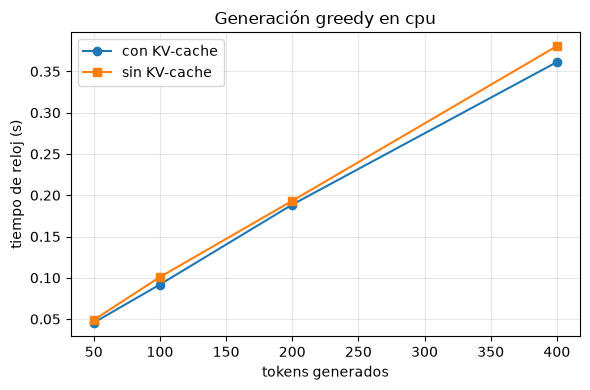

In [18]:
def benchmark_cache(lengths=(50, 100, 200, 400), repeats: int = 5):
    """
    Para cada largo, cronometrar la generación con use_cache=True y use_cache=False e
    imprimir el speed-up. Graficar tokens vs. tiempo de reloj para ambos.
    """
    kw = dict(model=model, tokenizer=tokenizer, prompt="To be", do_sample=False)
    # Calentamiento: la primera llamada paga asignaciones del allocator y no es representativa.
    for use_cache in (True, False):
        generateV2(**kw, max_new_tokens=20, use_cache=use_cache)

    tiempos = {True: [], False: []}
    print(f"{'tokens':>6} | {'con cache':>10} | {'sin cache':>10} | speed-up")
    for n in lengths:
        # Alternar con/sin cache en cada repetición: esta CPU (laptop) baja la frecuencia con la
        # temperatura, y medir todas las de un lado primero mediría el throttling, no el cache.
        muestras = {True: [], False: []}
        for _ in range(repeats):
            for use_cache in (True, False):
                t0 = time.perf_counter()
                generateV2(**kw, max_new_tokens=n, use_cache=use_cache)
                muestras[use_cache].append(time.perf_counter() - t0)
        for use_cache in (True, False):
            tiempos[use_cache].append(sorted(muestras[use_cache])[repeats // 2])  # mediana
        con, sin = tiempos[True][-1], tiempos[False][-1]
        print(f"{n:>6} | {con:>9.3f}s | {sin:>9.3f}s | {sin / con:.2f}x")

    plt.figure(figsize=(6, 4))
    plt.plot(lengths, tiempos[True], marker="o", label="con KV-cache")
    plt.plot(lengths, tiempos[False], marker="s", label="sin KV-cache")
    plt.xlabel("tokens generados")
    plt.ylabel("tiempo de reloj (s)")
    plt.title(f"Generación greedy en {device}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return tiempos


cache_times = benchmark_cache()

## Preguntas

1. ¿El cache hizo la generación más rápida? Reportá tus números. Si no la hizo más rápida,
   explicá adónde se va realmente el tiempo: contá los lanzamientos de kernel y las
   asignaciones de tensores que hace esta implementación por paso de decodificación, y
   pesalos contra la aritmética que el cache ahorra.
2. Asintóticamente el cache es una ganancia clara. Nombrá las propiedades específicas de
   *esta* implementación y de *este* tamaño de modelo que esconden esa ganancia, y describí
   un escenario (tamaño de modelo, largo de secuencia, implementación de atención) donde se
   vería con claridad.
3. ¿Qué te cuesta el cache en memoria? Dá la fórmula en términos de `n_layer`, `n_head`,
   `head_dim`, tamaño de batch y largo de secuencia, y evaluala para este modelo.
4. La decodificación con y sin cache produce texto idéntico mientras la secuencia entra en
   la ventana de contexto, y diverge después. ¿Por qué?

---

**Respuestas**

1. **El cache prácticamente no hizo más rápida la generación.** Medianas de 5 repeticiones, greedy, en CPU:

   | tokens | con cache | sin cache | speed-up |
   |---:|---:|---:|---:|
   | 50 | 0,046 s | 0,049 s | 1,07x |
   | 100 | 0,092 s | 0,101 s | 1,10x |
   | 200 | 0,189 s | 0,193 s | 1,02x |
   | 400 | 0,361 s | 0,381 s | 1,05x |

   Las dos curvas son rectas casi superpuestas, de ~0,9 ms por token. La diferencia, (0,381 − 0,361) / 400 ≈ 0,05 ms por token, es todo lo que cuesta recalcular los ~31 tokens anteriores: alrededor del 5 % del paso.

   **Adónde se va el tiempo.** Cada paso de decodificación con cache lanza unas 50 operaciones de PyTorch, y unas 15–20 de ellas alocan un tensor nuevo:
   - **Embedding:** embedding de token, `arange` de posiciones, embedding de posición y la suma.
   - **Por cada una de las 2 capas (~20 operaciones):** `ln1`; la `Linear` de qkv; `chunk` y tres `view`/`transpose`; dos `torch.cat` para K y V, que realocan y copian el cache entero; un `torch.stack` que vuelve a copiar K y V completos; `q @ kᵀ`; el escalado; `masked_fill`; `softmax`; `wei @ v`; `transpose` + `contiguous`, que es otra copia; `proj`; la suma residual; `ln2`; `Linear`-`ReLU`-`Linear`; y la segunda suma residual.
   - **Fuera del modelo:** `ln_f`, `head`, el recorte de los logits, la división por temperatura, el `argmax`, el `torch.cat` de `idx` y `trim_kv_cache`, que hace un slice por capa.

   Cada operación paga un overhead fijo de dispatch de Python/PyTorch del orden de 5–20 µs, y eso ya explica el ~1 ms por token. Sin cache, el modelo hace **las mismas** ~50 operaciones, sólo que sobre 32 filas en vez de 1. La aritmética extra son unos pocos millones de MACs, que en matmuls de 32×64 son microsegundos. Además el cache no es gratis: `cat` + `stack` copian todo K y V en cada paso. Las dos versiones están dominadas por el overhead por operación, que es idéntico.

2. **Por qué no se ve la ganancia acá:**
   - **`block_size=32`:** sin cache nunca se recalculan más de 32 tokens, así que el costo sin cache también es lineal, O(N·32), y no O(N²). La ganancia teórica queda acotada a un factor constante chico.
   - **Modelo diminuto** (`n_embd=64`, 2 capas, 4 cabezas): la aritmética es despreciable frente al overhead por operación, así que procesar 1 o 32 tokens cuesta casi lo mismo.
   - **Batch 1, CPU, PyTorch eager:** sin `torch.compile` ni kernels fusionados.
   - **Cache con `torch.cat` + `torch.stack`:** realoca y copia K/V en cada paso, y esas copias O(T) se comen parte del ahorro.

   **Dónde se vería con claridad:** un modelo tipo GPT-2 medium o LLaMA-7B (d = 1024–4096, 24–32 capas), con contexto de 2k–8k tokens, en GPU, con un cache **preasignado** (estático o paginado, como vLLM) y atención con SDPA/FlashAttention para decode. Ahí, sin cache, el paso *n* recalcula proyecciones y FFN de *n* tokens con matmuls enormes (O(N²) en total), mientras que con cache procesa uno solo. Las ganancias son de un orden de magnitud o más.

3. **Costo en memoria.** La fórmula es:

   $$M = 2\,(K\text{ y }V) \times n\_layer \times n\_head \times head\_dim \times B \times T \times \text{bytes por elemento}$$

   Como $n\_head \times head\_dim = n\_embd$, para este modelo en fp32 con la ventana llena da $2 \times 2 \times 4 \times 16 \times 1 \times 32 \times 4\,\text{B} = 32.768\,\text{B} = 32\,\text{KB}$ por secuencia (1 KB por token). Es nada comparado con los pesos: 106.048 parámetros × 4 B ≈ 424 KB. Para tener una referencia, LLaMA-2-7B (32 capas, 32 cabezas, `head_dim` 128, fp16) necesita 512 KB por token, o sea 2 GB por secuencia de 4.096 tokens. A esa escala la memoria del cache es lo que limita el batch del serving.

4. **Por qué diverge el texto.** Mientras la secuencia entra en la ventana, las dos versiones calculan exactamente lo mismo: los K/V cacheados son los que se recalcularían, con las mismas posiciones y la misma máscara. Cuando la secuencia pasa de `block_size`, las dos versiones se separan:
   - **Sin cache:** el contexto se recorta a los últimos 32 caracteres y se recalcula todo con posiciones 0..31, así que cada token "se corre" una posición.
   - **Con cache:** `trim_kv_cache` descarta los K/V más viejos, pero los que quedan conservan el embedding de posición con el que se calcularon, y el token nuevo entra siempre en la posición 31.

   Además, en la capa 2 los K/V de cada token dependen de la salida de la capa 1, que atendió a caracteres que ya salieron de la ventana. Por eso ni siquiera con posiciones relativas (RoPE) sería exacto. Los logits dejan de coincidir, y con greedy alcanza con que cambie un solo arg-max para que el resto del texto diverja.

# Consigna IV — visualizar la atención

Un GPT completa texto. Veamos a qué atienden realmente las cabezas de tu modelo
entrenado.

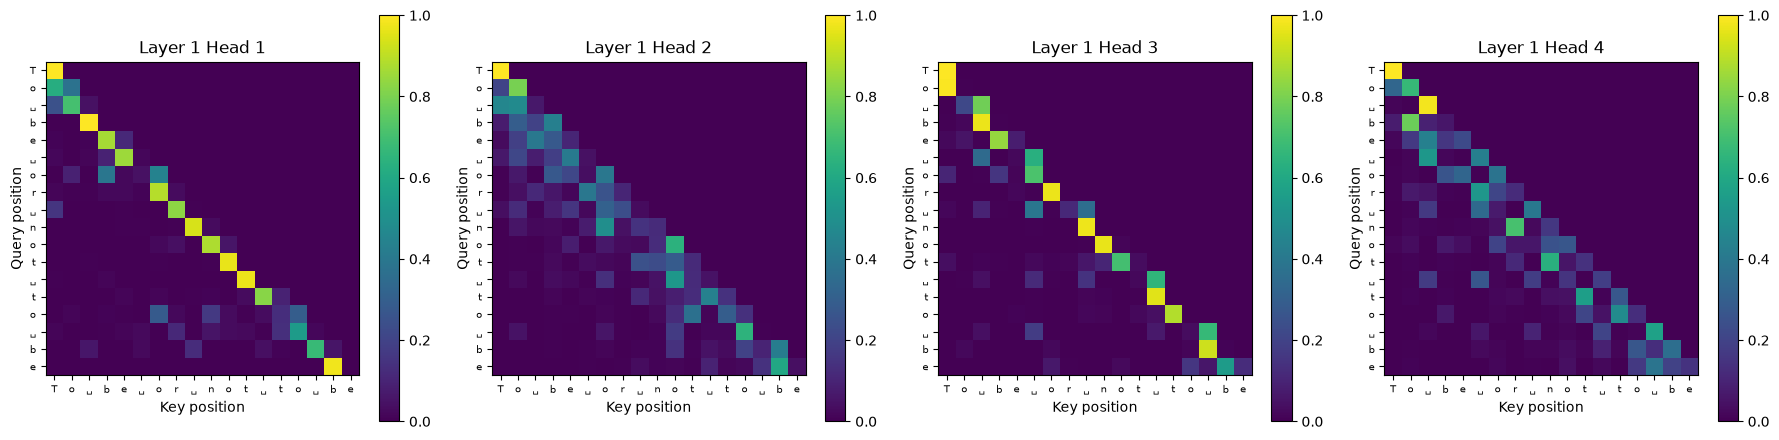

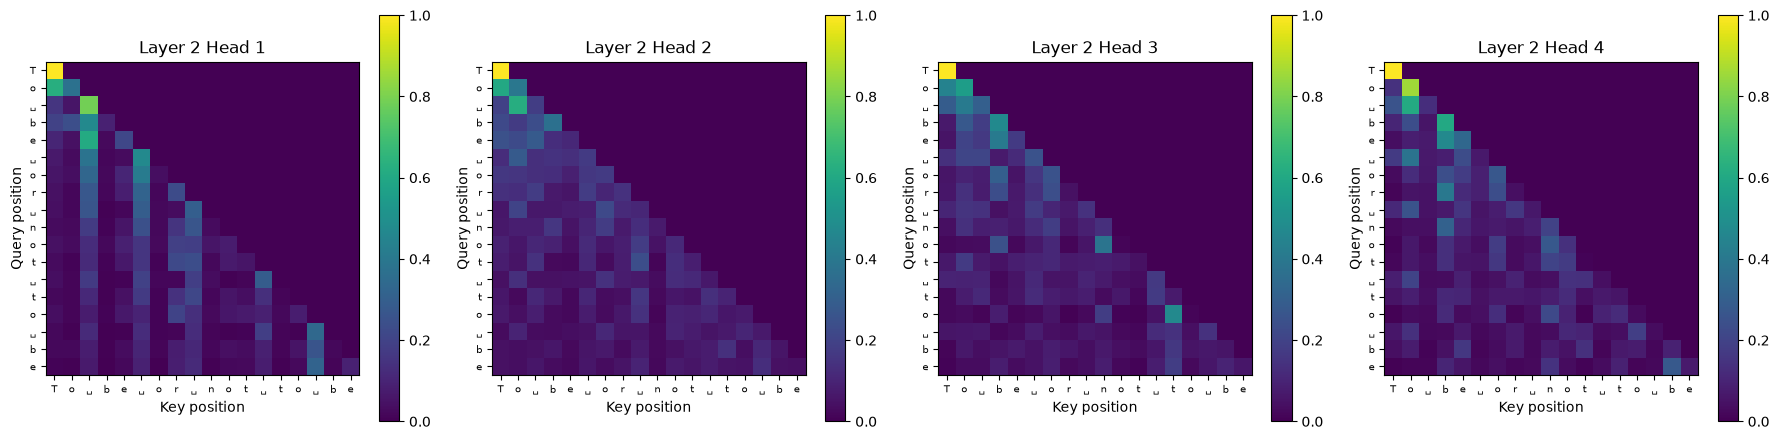

In [19]:
visualize_attention(model, tokenizer, "To be or not to be")

## Preguntas

1. Todos los mapas son triangulares inferiores. ¿Qué línea de `AttentionHead.forward` causa
   eso, y qué se rompería si la sacaras?
2. Encontrá una cabeza que atienda mayormente al carácter inmediatamente anterior y otra
   que reparta su masa más ampliamente. ¿Qué está haciendo cada una, plausiblemente?

---

**Respuestas**

1. **La máscara causal.** En esta implementación (`MultiHeadAttention.forward`, la versión batcheada que reemplaza a `AttentionHead`) la triangularidad la causa esta línea:

   ```python
   wei = wei.masked_fill(self.tril[past:T_k, :T_k] == 0, float("-inf"))
   ```

   La línea pone −∞ en los scores de las keys posteriores a cada query, y después del softmax esos pesos valen 0. Si se saca, en entrenamiento cada posición ve los caracteres futuros, incluido el que tiene que predecir. El modelo aprende a copiar el siguiente carácter y la loss de entrenamiento se va casi a 0 (fuga de información), pero en generación el futuro no existe y sale basura. También se rompería la equivalencia con el KV-cache. El slicing con `past` es lo que mantiene la máscara correcta cuando hay cache.

2. **Medí a qué atiende cada cabeza** con el checkpoint denso sobre `"To be or not to be"`, promediando por posición:
   - **Capa 1, cabeza 1:** pone el **75 %** de su masa en el carácter inmediatamente anterior, con entropía 0,67 nats y distancia media 1,5. Es una cabeza "de carácter previo": le pasa a cada posición la identidad del carácter anterior, que es justo lo que necesita un modelo de bigramas/trigramas para predecir el próximo carácter. La cabeza 3 de la capa 1 hace algo parecido (64 % al anterior).
   - **Capa 2, cabeza 2:** la más difusa (entropía 2,04, distancia media 4,0; sólo 18 % al anterior y 18 % a sí misma). Reparte la masa sobre todo el prefijo, como un promedio del contexto: un resumen tipo "bolsa de caracteres" de lo que vino antes (si estamos en una línea de diálogo, en un nombre en mayúsculas, etc.).
   - **Capa 2, cabeza 1:** pone el **59 %** de su masa en los espacios. En el mapa se ven columnas verticales sobre los `␣`: muchas queries miran al último espacio. Plausiblemente sigue dónde empezó la palabra actual, es decir, la posición dentro de la palabra.

---

# Parte 2 — Arquitectura

La Parte 1 cambió cómo *muestreás* de un modelo entrenado. La Parte 2 cambia el modelo
mismo.

Vas a reemplazar el bloque feed-forward denso por un Mixture of Experts — la idea detrás de
Mixtral, DeepSeek y Qwen-MoE — y compararlo contra el modelo que acabás de entrenar. No hay
que reentrenar el baseline: el `model` y la `history` de la Parte 1 son la comparación.

En un transformer denso todo token pasa por la *misma* red feed-forward. Un MoE reemplaza
esa única FFN por `E` expertos y una compuerta chica (*gate*) que elige `k` de ellos por
token. Los parámetros totales crecen con `E`; los parámetros *usados* para un token dado
crecen sólo con `k`. Comprás capacidad sin pagar el cómputo correspondiente.

Los costos también son reales, y los vas a medir: la gate puede colapsar sobre unos pocos
expertos y dejar al resto sin nada, el ruteo es discreto así que los gradientes sólo llegan
a los expertos que fueron seleccionados, y una implementación ingenua es *más lenta* que la
densa a esta escala.

### Referencias
- [Mixtral of Experts](https://arxiv.org/abs/2401.04088)
- [Outrageously Large Neural Networks (sparsely-gated MoE)](https://arxiv.org/abs/1701.06538)
- [Switch Transformers](https://arxiv.org/abs/2101.03961)
- `Clase_IV_MoEs.pdf`


In [20]:
def build_trainer(model, save_dir, lr=1e-3):
    """Mismo optimizador, scheduler y loss en toda corrida, así lo único que cambia es la arquitectura."""
    optimizer = make_optimizer(model.parameters(), lr=lr)
    scheduler = StepLR(optimizer, step_size=100, gamma=0.9)
    return Trainer(
        model=model,
        train_data_loader=train_loader,
        test_data_loader=val_loader,
        loss_fn=torch.nn.CrossEntropyLoss(),
        gradient_accumulation_steps=1,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        save_dir=save_dir,
        save_every_n=500,
    )

## Los bloques de construcción

Dos piezas, ambas dadas.

Un experto es una FFN: la misma pila `Linear -> ReLU -> Linear -> Dropout` que usa el
modelo denso. Nada exótico — lo interesante es a quién se rutea hacia él.

La gate puntúa cada experto para cada token, mapeando `(B, T, n_embd)` a
`(B, T, num_experts)`. Un solo `nn.Linear`, sin bias, sin activación; el softmax pasa
después, y sólo sobre los scores del top-k.

`Expert` toma su ancho oculto de `config.moe_args.expert_hidden_mult` en vez de hardcodear
4x. Vas a necesitar eso en la Consigna VIII.


In [21]:
class Expert(nn.Module):
    """
    Una sola MLP experta dentro de una capa MoE.

    El ancho oculto viene de moe_args.expert_hidden_mult (4.0 es lo estándar), para que la
    segmentación fina pueda achicar cada experto sin tocar esta clase.
    """

    def __init__(self, config: GPTConfig) -> None:
        super().__init__()
        hidden = int(config.moe_args.expert_hidden_mult * config.n_embd)
        self.net = nn.Sequential(
            nn.Linear(config.n_embd, hidden),
            nn.ReLU(),
            nn.Linear(hidden, config.n_embd),
            nn.Dropout(config.dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class Gate(nn.Module):
    """
    Router: puntúa cada experto para cada token. Devuelve logits crudos, no probabilidades.
    """

    def __init__(self, config: GPTConfig) -> None:
        super().__init__()
        self.proj = nn.Linear(config.n_embd, config.moe_args.num_experts, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.proj(x)


# Consigna V — ruteo top-k

Este es el núcleo del trabajo. `MoELayer.forward` recibe `x` de forma `(B, T, n_embd)` y
devuelve la misma forma.

La gate puntúa cada experto para cada token; te quedás con los `k` mejores, hacés softmax
sólo sobre esos, corrés cada experto seleccionado, y combinás su salida ponderada por la
gate. El ruteo es por token, no por secuencia — así que aplaná `(B, T, C)` a `(N, C)` antes
de rutear.

Dos cosas para tener bien, porque las dos fallan en silencio:

- El softmax va *después* del top-k, sólo sobre los expertos seleccionados. Normalizar
  antes de truncar deja pesos por token que ya no suman 1.
- Todo tiene que seguir siendo diferenciable, o la gate nunca aprende.

Antes de retornar, guardá la decisión de ruteo en el módulo —
`self.last_indices = indices.detach()` y
`self.last_gate_probs = F.softmax(logits, dim=-1).detach()` — la Consigna VII los lee.

In [22]:
class MoELayer(nn.Module):
    """
    Capa feed-forward Mixture of Experts con compuerta sparse.
    """

    def __init__(self, experts: List[nn.Module], gate: nn.Module, moe_args: MoEArgs):
        super().__init__()
        self.experts = nn.ModuleList(experts)
        self.gate = gate
        self.args = moe_args
        self.last_indices = None
        self.last_gate_probs = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape
        x_flat = x.reshape(-1, C)                                   # (N, C): se rutea por token

        logits = self.gate(x_flat)                                  # (N, E)
        weights, indices = torch.topk(logits, self.args.num_experts_per_token, dim=-1)  # (N, k)
        # Softmax DESPUÉS del top-k y sólo sobre los elegidos: los k pesos de cada token suman 1.
        # Los pesos salen de los logits, así que el gradiente llega a la gate por acá.
        weights = F.softmax(weights, dim=-1)

        out = torch.zeros_like(x_flat)
        for i, expert in enumerate(self.experts):
            token_idx, slot = torch.where(indices == i)             # tokens que eligieron al experto i
            if token_idx.numel() == 0:
                continue
            y = expert(x_flat[token_idx]) * weights[token_idx, slot, None]
            out.index_add_(0, token_idx, y)

        self.last_indices = indices.detach()
        self.last_gate_probs = F.softmax(logits, dim=-1).detach()
        return out.view(B, T, C)


class MoEFFN(nn.Module):
    """
    Reemplazo directo de FeedForward. Se asigna a config.ff_class para que Block lo tome
    sin ningún cambio en el código del modelo.
    """

    def __init__(self, config: GPTConfig):
        super().__init__()
        assert config.moe_args is not None, "hay que setear config.moe_args para usar MoEFFN"
        self.moe = MoELayer(
            experts=[Expert(config) for _ in range(config.moe_args.num_experts)],
            gate=Gate(config),
            moe_args=config.moe_args,
        )

    def forward(self, x):
        return self.moe(x)

## Self-check

Corré esto antes de entrenar. Cuesta segundos y atrapa los bugs de ruteo que si no
aparecerían como una curva de loss plana media hora más tarde.

In [23]:
def check_moe():
    cfg = GPTConfig(vocab_size=tokenizer.vocab_size, n_embd=32, dropout=0.0,
                    moe_args=MoEArgs(num_experts=4, num_experts_per_token=2))
    layer = MoELayer([Expert(cfg) for _ in range(4)], Gate(cfg), cfg.moe_args)
    layer.eval()
    x = torch.randn(2, 5, 32)

    # 1. se preserva la forma
    out = layer(x)
    assert out.shape == x.shape, f"{out.shape} != {x.shape}"

    # 2. los gradientes llegan tanto a los expertos como a la gate
    out.sum().backward()
    assert layer.gate.proj.weight.grad is not None, "la gate no recibe gradiente"
    assert any(p.grad is not None and p.grad.abs().sum() > 0
               for p in layer.experts.parameters()), "ningún experto recibe gradiente"

    # 3. con k=1 la salida tiene que ser igual a la del experto seleccionado, sin tocar
    cfg1 = GPTConfig(vocab_size=tokenizer.vocab_size, n_embd=32, dropout=0.0,
                     moe_args=MoEArgs(num_experts=4, num_experts_per_token=1))
    top1 = MoELayer([Expert(cfg1) for _ in range(4)], Gate(cfg1), cfg1.moe_args)
    top1.eval()
    with torch.no_grad():
        y = top1(x)
        choice = top1.gate(x).argmax(dim=-1)          # (B, T)
        expected = torch.stack([
            torch.stack([top1.experts[int(choice[b, t])](x[b, t]) for t in range(x.shape[1])])
            for b in range(x.shape[0])
        ])
    err = (y - expected).abs().max().item()
    assert err < 1e-5, f"discrepancia en el ruteo top-1: {err}"

    # 4. el ruteo tiene que ser por token, no por secuencia
    assert top1.last_indices is not None, "guardá last_indices (ver Consigna V)"
    assert top1.last_indices.shape[0] == x.shape[0] * x.shape[1]

    print("todos los checks pasaron")


check_moe()

todos los checks pasaron


# Consigna VI — entrenar TinyGPT-MoE

`Block` lee `config.ff_class`, así que convertir TinyGPT en un MoE es un cambio de
configuración, no un cambio de código.

In [24]:
moe_config = GPTConfig(
    vocab_size=tokenizer.vocab_size,
    ff_class=MoEFFN,
    moe_args=MoEArgs(num_experts=4, num_experts_per_token=2),
)

moe_model = TinyGPT(moe_config).to(device)
if device == "cuda":
    moe_model = torch.compile(moe_model)

describe(model, "TinyGPT (denso)")
describe(moe_model, f"TinyGPT-MoE (E={moe_config.moe_args.num_experts}, k={moe_config.moe_args.num_experts_per_token})")

dense_total, _ = count_parameters(model)
moe_total, _ = count_parameters(moe_model)
print(f"\ncrecimiento de parámetros: {moe_total / dense_total:.2f}x")

TinyGPT (denso): 106,048 parameters | 106,048 trainable (100.00%)
TinyGPT-MoE (E=4, k=2): 305,088 parameters | 305,088 trainable (100.00%)

crecimiento de parámetros: 2.88x


mixed precision: off


  0%|          | 0/1405 [00:00<?, ?it/s]

  0%|          | 2/1405 [00:00<01:21, 17.11it/s]

  0%|          | 4/1405 [00:00<01:15, 18.57it/s]

  0%|          | 7/1405 [00:00<01:09, 20.22it/s]

...

val_loss 1.57921:  98%|█████████▊| 152/155 [00:02<00:00, 59.10it/s]

val_loss 1.52902:  98%|█████████▊| 152/155 [00:02<00:00, 59.10it/s]

val_loss 2.13499:  98%|█████████▊| 152/155 [00:02<00:00, 59.10it/s]

val_loss 2.13499: 100%|██████████| 155/155 [00:02<00:00, 56.00it/s]

epoch 2/2 | train 2.0165 | val 1.8877


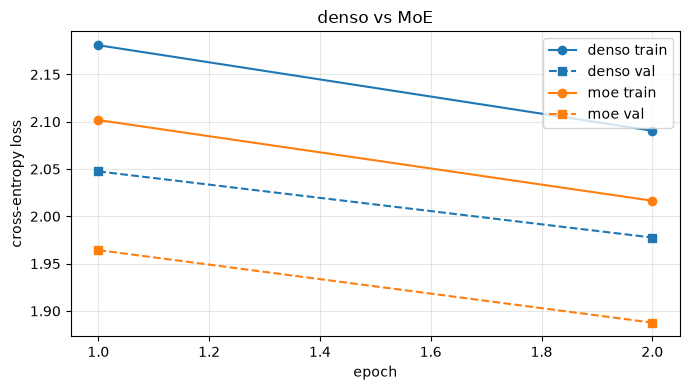

In [25]:
history_moe = run_training(build_trainer(moe_model, "./checkpoints/tp1_moe"), epochs=EPOCHS)
plot_losses({"denso": history, "moe": history_moe}, title="denso vs MoE")
free()

# Consigna VII — utilización de expertos

Un MoE que rutea el 90% de sus tokens a un solo experto es un modelo denso que desperdicia
memoria. Medí si el tuyo realmente reparte la carga.

Usando `last_indices` (que guarda tu `MoELayer.forward`), corré unos pocos batches de
validación y, por capa, contá cuántos tokens fueron a cada experto. Graficalo como un
gráfico de barras, un grupo por capa, e imprimí la fracción de tokens que vio cada experto.

Una capa perfectamente balanceada manda `k / E` de los tokens a cada experto.

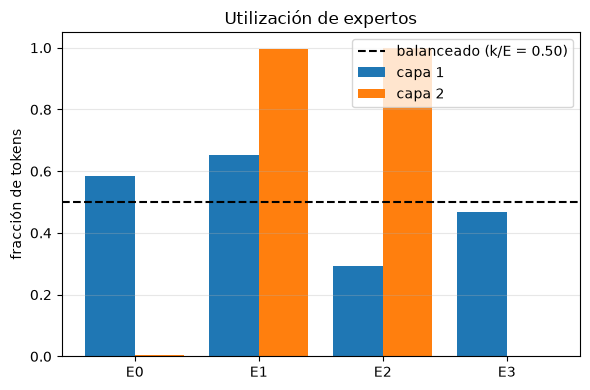

capa 1: E0=0.586  E1=0.653  E2=0.292  E3=0.469   (máx/mín = 2.24x)
capa 2: E0=0.004  E1=0.996  E2=1.000  E3=0.000   (máx/mín = 5851.43x)


In [26]:
@torch.no_grad()
def expert_utilization(model, loader, n_batches: int = 20, title: str = "Utilización de expertos"):
    """
    Devuelve un tensor de forma (n_layer, num_experts) con la fracción de tokens ruteados
    a cada experto, y lo grafica.

    Pista: para cada bloque, model.blocks[i].ff.moe.last_indices tiene la selección (N, k)
    del forward más reciente. Usá torch.bincount.
    """
    model.eval()
    dev = next(model.parameters()).device
    moes = [block.ff.moe for block in model.blocks]
    E, k = moes[0].args.num_experts, moes[0].args.num_experts_per_token

    counts = torch.zeros(len(moes), E)
    n_tokens = 0
    for b, (xb, _) in enumerate(loader):
        if b == n_batches:
            break
        model(xb.to(dev))
        n_tokens += xb.numel()
        for layer, moe in enumerate(moes):
            counts[layer] += torch.bincount(moe.last_indices.flatten().cpu(), minlength=E).float()

    # Fracción de tokens que vio cada experto. Cada token elige k, así que balanceado = k / E.
    frac = counts / n_tokens

    width = 0.8 / len(moes)
    plt.figure(figsize=(max(6, 1.2 * E), 4))
    for layer in range(len(moes)):
        plt.bar([e + layer * width for e in range(E)], frac[layer].tolist(), width=width,
                label=f"capa {layer + 1}")
    plt.axhline(k / E, color="k", linestyle="--", label=f"balanceado (k/E = {k / E:.2f})")
    plt.xticks([e + width * (len(moes) - 1) / 2 for e in range(E)], [f"E{e}" for e in range(E)])
    plt.ylabel("fracción de tokens")
    plt.title(title)
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    for layer in range(len(moes)):
        fila = "  ".join(f"E{e}={frac[layer, e]:.3f}" for e in range(E))
        mn = frac[layer].min()
        ratio = f"{frac[layer].max() / mn:.2f}x" if mn > 0 else "∞: hay expertos sin tokens"
        print(f"capa {layer + 1}: {fila}   (máx/mín = {ratio})")
    return frac


utilization = expert_utilization(moe_model, val_loader)

## Preguntas

1. Si un experto queda sin tokens, explicá el bucle de realimentación que te llevó ahí.
   ¿Por qué se refuerza a sí mismo?
2. El ruteo es un `topk`, que no tiene gradiente útil. Entonces, ¿cómo aprende algo la
   gate? Trazá el camino desde la loss hasta `gate.proj.weight`.

---

**Respuestas**

Utilización medida: en la capa 1 la carga está razonablemente repartida (E0 = 0,586, E1 = 0,653, E2 = 0,292, E3 = 0,469; máx/mín = 2,24x). En la capa 2 hubo colapso: E1 = 0,996 y E2 = 1,000 reciben prácticamente todos los tokens, mientras que E0 = 0,004 y E3 = 0,000. Con k = 2 y E = 4, esa capa es en los hechos una FFN densa de dos expertos.

1. **El bucle "rich get richer".** Al principio la gate, por la inicialización, puntúa un poco más alto a algunos expertos para muchos tokens. Esos expertos reciben más tokens, por lo tanto más gradiente, y mejoran más rápido. Como bajan más la loss, el gradiente hacia la gate sube todavía más sus logits relativos y les manda más tokens. Un experto que queda fuera del top-k de todos los tokens no participa del forward: no recibe gradiente, no mejora, y su fila en `gate.proj.weight` tampoco recibe gradiente por la vía del top-k. Nunca tiene la oportunidad de volver a ganar tokens, así que el colapso es un punto fijo estable. Eso es lo que pasó con E0 y E3 en la capa 2. Sin una loss auxiliar de balanceo no hay nada que empuje en sentido contrario.

2. **El camino del gradiente hasta la gate:**

   $$L \rightarrow \text{logits} \rightarrow \dots \rightarrow x + \mathrm{ff}(\mathrm{ln}_2(x)) \rightarrow out = \sum_{j \in \text{top-}k} w_j\, E_j(x) \rightarrow w = \mathrm{softmax}(\text{logits}_{\text{top-}k}) \rightarrow \text{logits} = \texttt{gate.proj}(x) \rightarrow \texttt{gate.proj.weight}$$

   `torch.topk` devuelve dos cosas: los **índices**, que son constantes a trozos y no tienen gradiente, y los **valores**, que son los logits seleccionados y sí son diferenciables. El gradiente no pasa por *qué* expertos se eligieron, pero sí por *cuánto pesa* cada uno. Para un token, $\partial L / \partial w_j = \langle \partial L / \partial out,\ E_j(x) \rangle$. Eso pasa por el jacobiano del softmax hacia los $k$ logits elegidos y de ahí a $\partial L / \partial W_{gate} = \sum_{\text{tokens}} (\partial L / \partial \text{logit}_j)\, x^\top$, sólo en las filas de los expertos seleccionados. La gate aprende **preferencias relativas entre los expertos que ya eligió**: sube el logit del que más reduce la loss. Indirectamente eso cambia el ranking y, en el paso siguiente, qué expertos entran en el top-k.

# Consigna VIII — DeepSeekMoE

Tu MoE actual es un diseño legacy: `E` expertos iguales, elegir los `k` mejores. Leé
[DeepSeekMoE (Dai et al., 2024)](https://arxiv.org/abs/2401.06066) e implementá sus dos
cambios. Son los que usan DeepSeek-V2 y V3 y las versiones modernas, y los dos son deltas
chicos sobre la capa que ya escribiste.

**Segmentación fina de expertos.** Partí cada experto en `m` más chicos: multiplicá
`num_experts` y `num_experts_per_token` por `m`, y dividí el ancho oculto de cada experto
por `m`. Los parámetros totales y el cómputo por token no cambian. Lo que crece es la
cantidad de *combinaciones* de ruteo — de "elegir 2 de 4" a "elegir 4 de 8" — así que un
token puede expresar una mezcla más específica.

**Aislamiento de expertos compartidos.** Reservá `num_shared_experts` expertos por los que
todo token pasa, siempre, por fuera del top-k. El argumento: el conocimiento común a todos
los tokens (puntuación, espaciado, inglés básico) si no tiene que duplicarse dentro de cada
experto ruteado. Entregáselo a un experto compartido y los ruteados quedan libres para
especializarse.

Implementá `DeepSeekMoELayer`. Las dos configuraciones ya viven en `MoEArgs`
(`num_shared_experts`, `expert_hidden_mult`); `Expert` lee el ancho de la config, así que
no deberías necesitar tocarlo.

Después entrenalo contra tu MoE de la Consigna VI con **parámetros activos igualados** y
reportá loss, utilización de expertos, y tiempo por paso.

### Fijá tus expectativas primero

Escribí qué predecís, y recién después medí. Este modelo es de 2 capas con `n_embd=64`
entrenado sobre 100k caracteres. Segmentar 4 expertos en 8 deja a cada uno con un ancho
oculto de 128. Los resultados del paper son a 2B–145B parámetros sobre cientos de miles de
millones de tokens.

**Un resultado nulo acá es el resultado correcto, y explicarlo es la consigna.** Reproducir
una arquitectura de 2024 y después reportar honestamente que su beneficio no aparece a tu
escala vale más que un número que salió para el lado correcto por suerte.

In [27]:
class DeepSeekMoELayer(nn.Module):
    """
    MoE con segmentación fina de expertos y expertos compartidos (arXiv:2401.06066).

    Los expertos compartidos corren para todo token, por fuera del top-k. Los ruteados se
    seleccionan como antes. Guardá last_indices / last_gate_probs sólo para los expertos
    ruteados, así el gráfico de utilización de la Consigna VII sigue funcionando.
    """

    def __init__(self, config: GPTConfig):
        super().__init__()
        args = config.moe_args
        self.args = args
        # Ruteados: el MoELayer de la Consigna V tal cual. La segmentación fina ya viene en la
        # config: más expertos, k más grande y expertos más angostos vía expert_hidden_mult.
        self.routed = MoELayer(
            experts=[Expert(config) for _ in range(args.num_experts)],
            gate=Gate(config),
            moe_args=args,
        )
        # Compartidos: por fuera del top-k, los atraviesa todo token.
        self.shared_experts = nn.ModuleList(Expert(config) for _ in range(args.num_shared_experts))
        self.last_indices = None
        self.last_gate_probs = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.routed(x)
        for expert in self.shared_experts:
            out = out + expert(x)
        self.last_indices = self.routed.last_indices
        self.last_gate_probs = self.routed.last_gate_probs
        return out


class DeepSeekMoEFFN(nn.Module):
    """Reemplazo directo para config.ff_class, igual que MoEFFN."""

    def __init__(self, config: GPTConfig):
        super().__init__()
        self.moe = DeepSeekMoELayer(config)

    def forward(self, x):
        return self.moe(x)

In [28]:
# La segmentación fina es neutra en cómputo: 4 expertos x top-2 con oculto 4.0x pasa a
# 8 x top-4 con 2.0x, y los parámetros activos de FFN por token son idénticos en ambos
# casos. Lo que cambia es la cantidad de combinaciones de ruteo, de C(4,2)=6 a C(8,4)=70.
#
# El experto compartido NO es gratis -- corre para todo token, sumando el equivalente a un
# experto por encima. La pregunta 1 te pide calcular exactamente cuánto, y si eso invalida
# la comparación.
#
# SEGMENTS=2 mantiene esto accesible: 8 expertos ruteados + 1 compartido son 9 llamadas
# secuenciales a expertos por capa, contra 17 con SEGMENTS=4. El paper segmenta mucho más
# agresivamente -- poné 4 si tenés el cómputo y querés ver si cambia algo.
SEGMENTS = 2

ds_config = GPTConfig(
    vocab_size=tokenizer.vocab_size,
    ff_class=DeepSeekMoEFFN,
    # Como en el paper (sección 3.2): el compartido se descuenta de los ruteados, así los
    # parámetros totales (8 segmentos = 4 expertos enteros) y los activos por token
    # (4 segmentos = 2 expertos enteros) quedan iguales a los del MoE de la Consigna VI.
    moe_args=MoEArgs(
        num_experts=4 * SEGMENTS - 1,
        num_experts_per_token=2 * SEGMENTS - 1,
        num_shared_experts=1,
        expert_hidden_mult=4.0 / SEGMENTS,
    ),
)

ds_model = TinyGPT(ds_config).to(device)
if device == "cuda":
    ds_model = torch.compile(ds_model)

describe(moe_model, "MoE (Consigna VI)")
describe(ds_model, "DeepSeekMoE")


MoE (Consigna VI): 305,088 parameters | 305,088 trainable (100.00%)
DeepSeekMoE: 305,984 parameters | 305,984 trainable (100.00%)


### Predicción (escrita antes de entrenar)

- **Loss:** resultado nulo. Con 2 capas, `n_embd=64` y 100k caracteres el cuello de botella son
  los datos, no la capacidad de ruteo. Pasar de C(4,2)=6 a C(7,3)=35 combinaciones no debería
  cambiar nada medible: espero una val loss dentro del ruido (±0.02) del MoE de la Consigna VI.
- **Utilización:** algo más despareja que con 4 expertos: 7 expertos ruteados para repartir los
  mismos tokens, cada uno ve menos datos y la gate tiene más formas de concentrarse.
- **Tiempo por paso:** peor: 7 ruteados + 1 compartido son 8 llamadas secuenciales a expertos por
  capa contra 4, con la misma aritmética total. A esta escala manda el overhead por llamada.

mixed precision: off


  0%|          | 0/1405 [00:00<?, ?it/s]

  0%|          | 1/1405 [00:00<07:37,  3.07it/s]

  0%|          | 2/1405 [00:00<08:50,  2.64it/s]

  0%|          | 3/1405 [00:01<08:20,  2.80it/s]

...

val_loss 1.58343:  97%|█████████▋| 150/155 [00:02<00:00, 57.31it/s]

val_loss 1.46442:  97%|█████████▋| 150/155 [00:02<00:00, 57.31it/s]

val_loss 2.13026:  97%|█████████▋| 150/155 [00:02<00:00, 57.31it/s]

val_loss 2.13026: 100%|██████████| 155/155 [00:02<00:00, 58.56it/s]

epoch 2/2 | train 1.9589 | val 1.8644


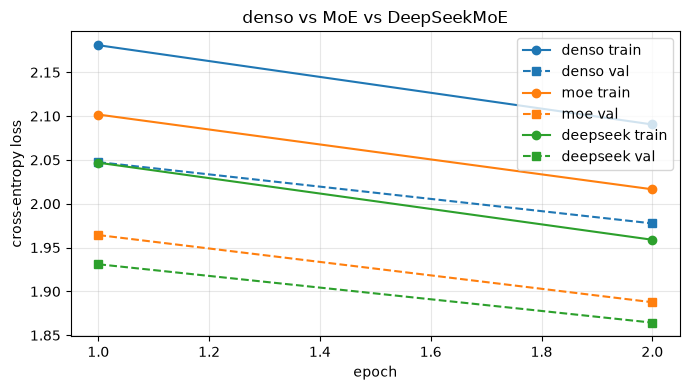

In [29]:
history_ds = run_training(build_trainer(ds_model, "./checkpoints/tp1_deepseek"), epochs=EPOCHS)
plot_losses({"denso": history, "moe": history_moe, "deepseek": history_ds},
            title="denso vs MoE vs DeepSeekMoE")
free()


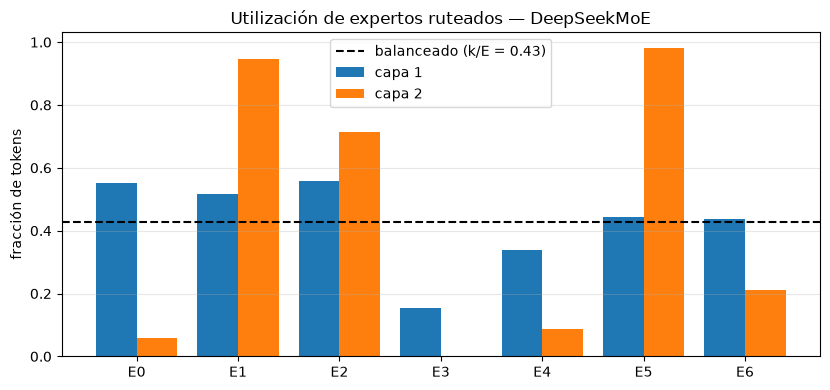

capa 1: E0=0.551  E1=0.518  E2=0.558  E3=0.154  E4=0.339  E5=0.442  E6=0.436   (máx/mín = 3.62x)
capa 2: E0=0.057  E1=0.948  E2=0.714  E3=0.000  E4=0.088  E5=0.982  E6=0.211   (máx/mín = 10056.75x)


capa 1: |compartido| = 8.529 | |un ruteado| = 18.714 | |suma ruteada| = 18.551 | cos(compartido, ruteado) = 0.883
capa 2: |compartido| = 2.661 | |un ruteado| = 9.237 | |suma ruteada| = 5.702 | cos(compartido, ruteado) = 0.847



modelo       | params totales | params activos | val loss | ms/paso
denso        |        106,048 |        106,048 |   1.9776 |    31.9
MoE          |        305,088 |        172,736 |   1.8877 |    59.6
DeepSeekMoE  |        305,984 |        173,376 |   1.8644 |    70.8


In [30]:
# Pregunta 1: utilización con 7 expertos ruteados
utilization_ds = expert_utilization(ds_model, val_loader, title="Utilización de expertos ruteados — DeepSeekMoE")


# Pregunta 2: magnitud de la salida del experto compartido vs. la de los ruteados
@torch.no_grad()
def shared_vs_routed(model, loader, n_batches: int = 10):
    """Norma L2 media por token, por capa: compartido, un ruteado suelto, y la suma ponderada de ruteados."""
    model.eval()
    dev = next(model.parameters()).device
    entradas = {i: [] for i in range(len(model.blocks))}
    hooks = [block.ff.register_forward_hook(lambda mod, inp, out, i=i: entradas[i].append(inp[0]))
             for i, block in enumerate(model.blocks)]
    for b, (xb, _) in enumerate(loader):
        if b == n_batches:
            break
        model(xb.to(dev))
    for hook in hooks:
        hook.remove()

    for i, block in enumerate(model.blocks):
        moe = block.ff.moe
        h = torch.cat(entradas[i]).flatten(0, 1)                     # (N, C) entrada a la FFN
        shared = sum(e(h) for e in moe.shared_experts)
        routed = moe.routed(h[None]).squeeze(0)                      # combinación ponderada top-k
        uno = []
        for e, expert in enumerate(moe.routed.experts):
            elegidos = (moe.routed.last_indices == e).any(dim=-1)
            if elegidos.any():
                uno.append(expert(h[elegidos]).norm(dim=-1).mean())
        cos = F.cosine_similarity(shared, routed, dim=-1).mean()
        print(f"capa {i + 1}: |compartido| = {shared.norm(dim=-1).mean():.3f} | "
              f"|un ruteado| = {torch.stack(uno).mean():.3f} | "
              f"|suma ruteada| = {routed.norm(dim=-1).mean():.3f} | "
              f"cos(compartido, ruteado) = {cos:.3f}")


shared_vs_routed(ds_model, val_loader)


# Tabla resumen: loss, parámetros y tiempo por paso
def parametros_activos(model) -> int:
    """Totales menos los expertos ruteados que un token NO usa (E - k por capa)."""
    total, _ = count_parameters(model)
    inactivos = 0
    for block in model.blocks:
        moe = block.ff.moe
        routed = moe.routed if hasattr(moe, "routed") else moe
        por_experto = sum(p.numel() for p in routed.experts[0].parameters())
        inactivos += (moe.args.num_experts - moe.args.num_experts_per_token) * por_experto
    return total - inactivos


def comparar_ms_por_paso(modelos: dict, loader, rondas: int = 7, pasos: int = 15, warmup: int = 3) -> dict:
    """
    Milisegundos por paso de entrenamiento (forward + backward + AdamW) de varios modelos, cada
    uno sobre una copia para no tocar los pesos entrenados. Las mediciones se intercalan por
    rondas, rotando el orden, y se reporta la mediana: esta CPU (laptop) baja la frecuencia con
    la temperatura, y medir un modelo después del otro mide el throttling, no el modelo.
    """
    import copy
    it = iter(loader)
    batches = [next(it) for _ in range(pasos)]            # siempre los mismos batches
    estado = {}
    for name, m in modelos.items():
        mc = copy.deepcopy(m).train()
        estado[name] = (mc, make_optimizer(mc.parameters()))

    def correr(mc, opt, n):
        for xb, yb in batches[:n]:
            logits = mc(xb.to(device))
            F.cross_entropy(logits.view(-1, logits.size(-1)), yb.to(device).view(-1)).backward()
            opt.step()
            opt.zero_grad(set_to_none=True)

    for mc, opt in estado.values():
        correr(mc, opt, warmup)
    nombres = list(modelos)
    medidas = {name: [] for name in nombres}
    for r in range(rondas):
        for name in nombres[r % len(nombres):] + nombres[:r % len(nombres)]:
            mc, opt = estado[name]
            t0 = time.perf_counter()
            correr(mc, opt, pasos)
            medidas[name].append((time.perf_counter() - t0) / pasos * 1000)
    return {name: sorted(v)[len(v) // 2] for name, v in medidas.items()}


ms_viii = comparar_ms_por_paso({"denso": model, "MoE": moe_model, "DeepSeekMoE": ds_model}, train_loader)
print(f"\n{'modelo':<12} | {'params totales':>14} | {'params activos':>14} | {'val loss':>8} | {'ms/paso':>7}")
total, _ = count_parameters(model)
print(f"{'denso':<12} | {total:>14,} | {total:>14,} | {history['val'][-1]:>8.4f} | {ms_viii['denso']:>7.1f}")
for name, m, h in (("MoE", moe_model, history_moe), ("DeepSeekMoE", ds_model, history_ds)):
    total, _ = count_parameters(m)
    print(f"{name:<12} | {total:>14,} | {parametros_activos(m):>14,} | {h['val'][-1]:>8.4f} | {ms_viii[name]:>7.1f}")

## Preguntas

1. Volvé a correr el gráfico de utilización de la Consigna VII sobre el modelo DeepSeekMoE.
   Con 8 expertos ruteados en vez de 4, ¿la carga queda más o menos balanceada, y por qué
   lo esperarías *antes* de mirar?
2. El experto compartido recibe todos los tokens. Inspeccioná la magnitud de su salida
   contra la de un experto ruteado. ¿Está haciendo lo que el paper afirma — absorber
   estructura común — o simplemente se convirtió en una segunda FFN densa?
3. El paper reporta ganancias claras; vos probablemente no las reprodujiste. Dá la razón
   más probable, y describí el experimento más chico que testearía si la escala es la
   explicación.

---

**Respuestas**

Resultados (`SEGMENTS = 2`; como en la sección 3.2 del paper, el experto compartido se descuenta de los ruteados, así que son **7 ruteados con top-3 + 1 compartido**, con los mismos parámetros totales y activos que el MoE de la Consigna VI):

| modelo | params totales | params activos | val loss | ms/paso |
|---|---:|---:|---:|---:|
| denso | 106.048 | 106.048 | 1,9776 | 31,9 |
| MoE (E=4, k=2) | 305.088 | 172.736 | 1,8877 | 59,6 |
| DeepSeekMoE (7+1, k=3) | 305.984 | 173.376 | 1,8644 | 70,8 |

1. **Queda menos balanceada, y era esperable.**
   - **Capa 1:** los ruteados ven entre 0,154 y 0,558 de los tokens (máx/mín = 3,62x, contra 2,24x del MoE de 4 expertos).
   - **Capa 2:** vuelve a colapsar, y peor: E1 = 0,948 y E5 = 0,982 se llevan casi todo, E3 = 0,000, E0 = 0,057 y E4 = 0,088 (máx/mín ≈ 10.000x). El balanceado sería k/E = 3/7 ≈ 0,43.

   Antes de mirar lo esperaba así por tres razones. Con más expertos, cada uno ve menos tokens y el bucle de realimentación de la Consigna VII arranca desde diferencias iniciales más grandes en proporción. Hay más maneras de concentrarse. Y no hay ninguna loss de balanceo (el paper usa dos: a nivel experto y a nivel dispositivo). Es lo que escribí en la predicción.

2. **El experto compartido no hace lo que dice el paper; se parece más a una segunda FFN densa.** Normas medias por token:
   - **Capa 1:** |compartido| = 8,53, |un ruteado| = 18,71, |suma ruteada| = 18,55, cos(compartido, ruteado) = 0,883.
   - **Capa 2:** |compartido| = 2,66, |un ruteado| = 9,24, |suma ruteada| = 5,70, cos = 0,847.

   El compartido aporta menos de la mitad de la magnitud de la parte ruteada (0,46x y 0,47x). Además su salida apunta en **la misma dirección** que la suma ruteada (coseno 0,85–0,88). Si estuviera absorbiendo la estructura común para que los ruteados se especialicen, las dos salidas serían complementarias, con un coseno bajo. Con el coseno alto, el compartido calcula una versión más chica de lo mismo que calculan los ruteados, que en la capa 2 además colapsaron a dos expertos fijos. Todo eso es redundancia, no especialización.

3. **La razón más probable es la escala.** DeepSeekMoE dio 1,8644 contra 1,8877 (−0,023), justo en el borde del ruido de ±0,02 que predije, con una sola semilla, y es 19 % más lento por paso. No es la ganancia clara del paper. Este modelo tiene 2 capas, `n_embd=64`, expertos de 128 unidades ocultas, 100k caracteres y 2 épocas: está limitado por datos, no por la flexibilidad del ruteo. El paper trabaja con 2B–145B parámetros y cientos de miles de millones de tokens, y con losses de balanceo que acá no hay. Sin balanceo el ruteo colapsa, y la ventaja combinatoria de la segmentación fina (C(7,3) = 35 combinaciones contra C(4,2) = 6) nunca se usa.

   **Experimento mínimo para testearlo:** mismo código, MoE contra DeepSeekMoE con parámetros activos igualados, 3 semillas cada uno, en 3 escalas: (100k caracteres, `n_embd` 64, 2 capas), (1M, 128, 4) y (10M, 256, 6), todas con la loss de balanceo. Después se grafica la diferencia de bits/char (MoE − DeepSeekMoE) contra la escala, con barras de error por semilla. Si la escala es la explicación, la diferencia tiene que crecer con la escala y salir del ruido. Si se queda en cero, el problema es otro (por ejemplo, el colapso del ruteo).

# Consigna IX — hacelo rápido

A libro abierto. No hay solución de referencia ni checker.

Lo mediste en la Consigna VI: el MoE entrena a aproximadamente **30x el costo por paso**
del modelo denso, para *menos* aritmética. La Consigna VIII lo empeoró — 16 expertos en vez
de 4 significa 16 llamadas secuenciales a expertos por capa.

**Hacelo más rápido. Reportá qué probaste, qué funcionó, qué no, y por qué.**

Reglas: la salida tiene que seguir siendo numéricamente equivalente a tu implementación de
la Consigna V (escribí un test que lo pruebe), y el modelo tiene que seguir entrenando. Más
allá de eso, vale todo.

Algunas direcciones, no una checklist — no estás obligado a usar ninguna:

- Cronometrá la *segunda* época, nunca la primera: la compilación perezosa de kernels hace
  que la época 1 sea unas 2.4x más lenta y va a favorecer o arruinar cualquier cambio que
  hagas.
- ¿Adónde se va realmente el tiempo? Perfilá antes de optimizar. `torch.profiler`, o
  cronometrá las partes a mano. La respuesta no está donde la mayoría supone.
- `torch.where` devuelve un tensor de largo variable, así que fuerza una sincronización
  GPU→CPU. La llamás una vez por experto por capa.
- Ordenar los tokens por experto una sola vez convierte un scatter en slices contiguos.
- Rellenar cada experto hasta una capacidad fija hace que las formas sean estáticas, que es
  lo que te permite batchear los expertos en un solo `torch.bmm`. ¿Qué te cuesta en
  correctitud el padding por capacidad?
- Los matmuls chicos dejan la GPU ociosa. ¿En cuántos lanzamientos de kernel, como mínimo,
  podría hacerse esto?

**Entregable:** tu implementación correcta más rápida, el test de equivalencia, una
medición antes/después en el mismo hardware, y un informe corto del razonamiento —
incluyendo las cosas que probaste que la hicieron más lenta. Esas suelen ser la parte más
informativa.



SortedMoELayer   E=4 k=1: equivalente (error máx 0.0e+00)
SortedMoELayer   E=4 k=2: equivalente (error máx 0.0e+00)
SortedMoELayer   E=8 k=4: equivalente (error máx 0.0e+00)
BatchedMoELayer  E=4 k=1: equivalente (error máx 3.0e-07)


BatchedMoELayer  E=4 k=2: equivalente (error máx 2.4e-07)
BatchedMoELayer  E=8 k=4: equivalente (error máx 8.9e-08)
PaddedMoELayer   E=4 k=1: equivalente (error máx 3.0e-07)
PaddedMoELayer   E=4 k=2: equivalente (error máx 2.7e-07)


PaddedMoELayer   E=8 k=4: equivalente (error máx 8.9e-08)


TinyGPT-MoE con SortedMoELayer: logits iguales al original (error máx 0.0e+00)
TinyGPT-MoE con BatchedMoELayer: logits iguales al original (error máx 7.6e-06)
TinyGPT-MoE con PaddedMoELayer: logits iguales al original (error máx 4.8e-06)


STAGE:2026-09-29 12:34:23 73148:41980457 ActivityProfilerController.cpp:314] Completed Stage: Warm Up


...

val_loss 1.47135:  94%|█████████▎| 145/155 [00:02<00:00, 80.90it/s]

val_loss 1.47135:  99%|█████████▉| 154/155 [00:02<00:00, 73.30it/s]

val_loss 2.13683:  99%|█████████▉| 154/155 [00:02<00:00, 73.30it/s]

val_loss 2.13683: 100%|██████████| 155/155 [00:02<00:00, 75.14it/s]

epoch 2/2 | train 2.0010 | val 1.8798
tiempo total de entrenamiento: 205s


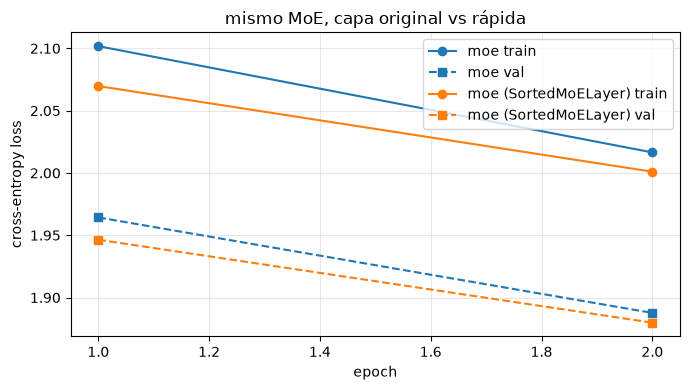

In [31]:
import copy
from dataclasses import replace


class SortedMoELayer(MoELayer):
    """
    Variante 1: ordenar las asignaciones (token, experto) por experto una sola vez. Cada experto
    procesa un slice contiguo, hay un único torch.bincount(...).tolist() como sincronización
    en vez de un torch.where por experto, y un solo index_add_ al final.
    """

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape
        x_flat = x.reshape(-1, C)
        logits = self.gate(x_flat)
        weights, indices = torch.topk(logits, self.args.num_experts_per_token, dim=-1)
        weights = F.softmax(weights, dim=-1)
        k = indices.size(1)

        flat_expert = indices.flatten()                               # (N*k,)
        order = torch.argsort(flat_expert, stable=True)
        token_of = order // k                                         # token de cada asignación
        counts = torch.bincount(flat_expert, minlength=len(self.experts)).tolist()

        chunks = x_flat[token_of].split(counts)
        y = torch.cat([expert(chunk) for expert, chunk in zip(self.experts, chunks)])
        y = y * weights.flatten()[order, None]
        out = torch.zeros_like(x_flat).index_add_(0, token_of, y)

        self.last_indices = indices.detach()
        self.last_gate_probs = F.softmax(logits, dim=-1).detach()
        return out.view(B, T, C)


class BatchedMoELayer(MoELayer):
    """
    Variante 2: sin loops ni tensores de largo variable. Se apilan los pesos de los E expertos
    y se corren TODOS sobre TODOS los tokens con tres einsum; la gate, con ceros fuera del
    top-k, decide qué se suma. Hace E/k veces la aritmética de las FFN (2x acá), a cambio de
    pasar de ~6 operaciones chicas por experto a un puñado de matmuls grandes.
    """

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape
        x_flat = x.reshape(-1, C)
        logits = self.gate(x_flat)
        weights, indices = torch.topk(logits, self.args.num_experts_per_token, dim=-1)
        weights = F.softmax(weights, dim=-1)
        dense_w = torch.zeros_like(logits).scatter(1, indices, weights)       # (N, E)

        w1 = torch.stack([e.net[0].weight for e in self.experts])              # (E, H, C)
        b1 = torch.stack([e.net[0].bias for e in self.experts])                # (E, H)
        w2 = torch.stack([e.net[2].weight for e in self.experts])              # (E, C, H)
        b2 = torch.stack([e.net[2].bias for e in self.experts])                # (E, C)
        h = F.relu(torch.einsum("nc,ehc->enh", x_flat, w1) + b1[:, None])      # (E, N, H)
        y = torch.einsum("enh,ech->enc", h, w2) + b2[:, None]                  # (E, N, C)
        y = self.experts[0].net[3](y)                                          # dropout (misma p)
        out = torch.einsum("ne,enc->nc", dense_w, y)

        self.last_indices = indices.detach()
        self.last_gate_probs = F.softmax(logits, dim=-1).detach()
        return out.view(B, T, C)


class PaddedMoELayer(MoELayer):
    """
    Variante 3: ordenar por experto y rellenar cada uno hasta la misma capacidad, así los E
    expertos corren juntos en un torch.baddbmm por capa lineal (formas estáticas por paso).
    Capacidad = el máximo real de tokens por experto: no se descarta ningún token, así que es
    exacta, pero cuanto más desbalanceado el ruteo, más filas de relleno se calculan de gusto.
    """

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape
        x_flat = x.reshape(-1, C)
        logits = self.gate(x_flat)
        weights, indices = torch.topk(logits, self.args.num_experts_per_token, dim=-1)
        weights = F.softmax(weights, dim=-1)
        E, k = len(self.experts), indices.size(1)

        flat_expert = indices.flatten()
        order = torch.argsort(flat_expert, stable=True)
        expert_sorted = flat_expert[order]
        token_of = order // k
        counts = torch.bincount(flat_expert, minlength=E)
        starts = torch.cumsum(counts, 0) - counts
        slot = torch.arange(order.numel(), device=x.device) - starts[expert_sorted]  # lugar dentro del experto
        cap = int(counts.max())                                                       # única sincronización

        buf = x_flat.new_zeros(E, cap, C)
        buf[expert_sorted, slot] = x_flat[token_of]
        w1 = torch.stack([e.net[0].weight for e in self.experts])              # (E, H, C)
        b1 = torch.stack([e.net[0].bias for e in self.experts])                # (E, H)
        w2 = torch.stack([e.net[2].weight for e in self.experts])              # (E, C, H)
        b2 = torch.stack([e.net[2].bias for e in self.experts])                # (E, C)
        h = F.relu(torch.baddbmm(b1[:, None], buf, w1.transpose(1, 2)))        # (E, cap, H)
        y = torch.baddbmm(b2[:, None], h, w2.transpose(1, 2))                  # (E, cap, C)
        y = self.experts[0].net[3](y)[expert_sorted, slot] * weights.flatten()[order, None]
        out = torch.zeros_like(x_flat).index_add_(0, token_of, y)

        self.last_indices = indices.detach()
        self.last_gate_probs = F.softmax(logits, dim=-1).detach()
        self.last_padding = E * cap / order.numel()   # filas calculadas / filas útiles
        return out.view(B, T, C)


def moe_ffn(layer_cls):
    """ff_class que usa `layer_cls` con los mismos nombres de módulos que MoEFFN (mismo state_dict)."""
    class FFN(nn.Module):
        def __init__(self, config: GPTConfig):
            super().__init__()
            args = config.moe_args
            self.moe = layer_cls([Expert(config) for _ in range(args.num_experts)], Gate(config), args)

        def forward(self, x):
            return self.moe(x)
    FFN.__name__ = f"{layer_cls.__name__}FFN"
    return FFN


# --- Test de equivalencia: salida, ruteo y gradientes iguales a la Consigna V ---------------
def test_equivalencia(layer_cls, E: int, k: int, atol: float = 1e-5):
    torch.manual_seed(0)
    cfg = GPTConfig(vocab_size=tokenizer.vocab_size, dropout=0.0,
                    moe_args=MoEArgs(num_experts=E, num_experts_per_token=k))
    ref = MoELayer([Expert(cfg) for _ in range(E)], Gate(cfg), cfg.moe_args)
    new = layer_cls([Expert(cfg) for _ in range(E)], Gate(cfg), cfg.moe_args)
    new.load_state_dict(ref.state_dict())

    x_ref = torch.randn(4, 32, cfg.n_embd, requires_grad=True)
    x_new = x_ref.detach().clone().requires_grad_(True)
    y_ref, y_new = ref(x_ref), new(x_new)
    assert torch.equal(ref.last_indices, new.last_indices), "cambió el ruteo"
    assert torch.allclose(y_ref, y_new, atol=atol), f"salida distinta: {(y_ref - y_new).abs().max():.2e}"

    g = torch.randn_like(y_ref)
    y_ref.backward(g)
    y_new.backward(g)
    assert torch.allclose(x_ref.grad, x_new.grad, atol=atol), "gradiente de la entrada distinto"
    for (name, p), (_, q) in zip(ref.named_parameters(), new.named_parameters()):
        gp = p.grad if p.grad is not None else torch.zeros_like(p)
        gq = q.grad if q.grad is not None else torch.zeros_like(q)
        assert torch.allclose(gp, gq, atol=atol), f"gradiente distinto en {name}"
    return (y_ref - y_new).abs().max().item()


for layer_cls in (SortedMoELayer, BatchedMoELayer, PaddedMoELayer):
    for E, k in ((4, 1), (4, 2), (8, 4)):
        err = test_equivalencia(layer_cls, E, k)
        print(f"{layer_cls.__name__:<16} E={E} k={k}: equivalente (error máx {err:.1e})")


# --- Mismo modelo entrenado de la Consigna VI, con la capa rápida: tiene que dar los mismos logits
variantes = {"MoELayer (Consigna V)": moe_model}
for layer_cls in (SortedMoELayer, BatchedMoELayer, PaddedMoELayer):
    m = TinyGPT(replace(moe_config, ff_class=moe_ffn(layer_cls))).to(device)
    m.load_state_dict(moe_model.state_dict())
    variantes[layer_cls.__name__] = m

xb, _ = next(iter(val_loader))
with torch.no_grad():
    ref_logits = moe_model.eval()(xb.to(device))
    for name, m in list(variantes.items())[1:]:
        err = (m.eval()(xb.to(device)) - ref_logits).abs().max().item()
        print(f"TinyGPT-MoE con {name}: logits iguales al original (error máx {err:.1e})")

# --- ¿Adónde se va el tiempo? Perfil de un paso del MoE original --------------------------
from torch.profiler import ProfilerActivity, profile

m = copy.deepcopy(moe_model).train()
xb, yb = next(iter(train_loader))
with profile(activities=[ProfilerActivity.CPU]) as prof:
    for _ in range(5):
        loss = F.cross_entropy(m(xb).view(-1, tokenizer.vocab_size), yb.view(-1))
        loss.backward()
print(prof.key_averages().table(sort_by="self_cpu_time_total", row_limit=12))
del m

# --- Antes / después, mismo hardware (intercalado por rondas, mediana) ---------------------
tiempos_paso = comparar_ms_por_paso({"denso": model, **variantes, "DeepSeekMoE (Consigna VIII)": ds_model},
                                    train_loader)

base = tiempos_paso["MoELayer (Consigna V)"]
print(f"\n{'modelo':<28} | {'ms/paso':>8} | vs denso | vs MoE original")
for name, ms in tiempos_paso.items():
    print(f"{name:<28} | {ms:>8.1f} | {ms / tiempos_paso['denso']:>7.2f}x | {base / ms:>6.2f}x más rápido")

with torch.no_grad():
    variantes["PaddedMoELayer"].eval()(next(iter(val_loader))[0].to(device))
relleno = [block.ff.moe.last_padding for block in variantes["PaddedMoELayer"].blocks]
print("filas calculadas / útiles con relleno por capacidad, por capa:", [f"{r:.2f}x" for r in relleno])

# --- Y sigue entrenando: la variante más rápida, desde cero, mismo presupuesto -------------
rapida = min(("SortedMoELayer", "BatchedMoELayer", "PaddedMoELayer"), key=tiempos_paso.get)
print(f"\nentrenando TinyGPT-MoE con {rapida} desde cero")
torch.manual_seed(1337)
fast_moe_model = TinyGPT(replace(moe_config, ff_class=moe_ffn(globals()[rapida]))).to(device)
t0 = time.perf_counter()
history_fast = run_training(build_trainer(fast_moe_model, "./checkpoints/tp1_moe_fast"), epochs=EPOCHS)
print(f"tiempo total de entrenamiento: {time.perf_counter() - t0:.0f}s")
plot_losses({"moe": history_moe, f"moe ({rapida})": history_fast},
            title="mismo MoE, capa original vs rápida")
free()

### Informe — Consigna IX

**Qué probé** (las tres variantes pasan el test de equivalencia contra la Consigna V: misma salida, mismo ruteo y mismos gradientes, con un error máximo ≤ 3·10⁻⁷ por capa y ≤ 7,6·10⁻⁶ en los logits del modelo entrenado):

1. **`SortedMoELayer`:** ordena las asignaciones (token, experto) una sola vez con `argsort`, cada experto procesa un slice contiguo, hace un único `bincount().tolist()` como sincronización en lugar de un `torch.where` por experto, y un solo `index_add_`.
2. **`BatchedMoELayer`:** apila los pesos de los E expertos y corre **todos** los expertos sobre **todos** los tokens con matmuls batcheados. La gate, con ceros fuera del top-k, decide qué se suma. No hay loops ni formas variables, pero hace E/k = 2x la aritmética de la FFN.
3. **`PaddedMoELayer`:** ordena por experto, rellena cada uno hasta la capacidad máxima real (sin descartar tokens, así que es exacta) y corre los E expertos juntos con un `baddbmm` por capa lineal.

**Antes / después** (CPU, ms por paso de entrenamiento, mediana de 7 rondas intercaladas):

| variante | ms/paso | vs MoE original |
|---|---:|---:|
| denso | 39,8 | 1,60x más rápido |
| MoE original (Consigna V) | 63,6 | 1,00x |
| `SortedMoELayer` | 65,7 | 0,97x |
| `PaddedMoELayer` | 84,7 | 0,75x |
| `BatchedMoELayer` | 109,4 | 0,58x |
| DeepSeekMoE (Consigna VIII) | 87,6 | 0,73x |

**Resultado: en este hardware ninguna variante le gana a la original.** `SortedMoELayer` empata dentro del ruido (es la "más rápida" de las tres), y entrenada desde cero llega al mismo lugar que el MoE original: val 1,8798 contra 1,8877, en 205 s. Las otras dos son más lentas.

**Por qué:**
- **El perfil manda.** Un paso del MoE original está dominado por la aritmética y las copias, no por la sincronización: `aten::mm` 18,8 %, `copy_` 7,9 %, `addmm` 7,5 %, `bernoulli_` del dropout 6,2 %, `clamp_min` de la ReLU 5,9 %, `index_put_` 3,6 %. En CPU no existe la sincronización GPU→CPU que fuerza `torch.where`, así que el costo que atacan las pistas (lanzamientos de kernel y syncs) acá casi no está. Por eso el MoE original es sólo 1,6x más lento que el denso, y no ~30x.
- **Batched** elimina los loops pero duplica la aritmética de la FFN. En CPU la aritmética sí cuesta, y pierde.
- **Padded** paga por el **relleno**: medí 1,38x filas calculadas por fila útil en la capa 1 y **2,00x en la capa 2**. Con el ruteo colapsado de la capa 2, dos expertos reciben todos los tokens, así que la capacidad es N y se calculan E·N filas para 2·N útiles. El padding por capacidad sólo es barato con ruteo balanceado; con capacidad fija (descartando tokens) sería más rápido, pero dejaría de ser exacto.
- **Sorted** ahorra los 4 `torch.where` pero agrega un `argsort` y un gather con copia: en CPU el balance da cero.

En GPU esperaría el orden inverso. Ahí el costo está en los ~6 kernels chicos por experto y en las sincronizaciones, y `Batched`/`Padded` reducen todo a un puñado de `bmm` grandes. El mínimo serían unos 2–3 lanzamientos por capa, con un kernel *grouped GEMM* como el de MegaBlocks. No pude medirlo porque no tengo GPU.

# Opcional — loss de balanceo de carga

El arreglo estándar para el colapso de ruteo es una loss auxiliar (Switch Transformer,
ec. 4):

$$L_{aux} = E \cdot \sum_{i=1}^{E} f_i \cdot P_i$$

donde $f_i$ es la fracción de tokens ruteados al experto $i$ y $P_i$ es la probabilidad
media que la gate le asigna al experto $i$. Se minimiza cuando ambas son uniformes.

Notá que $f_i$ viene de un `topk` y no lleva gradiente, mientras que $P_i$ viene de un
softmax y sí — el producto es lo que hace entrenable al término.

Implementala, agregá `total_loss = ce_loss + alpha * aux_loss` con `alpha` alrededor de
`0.01`, reentrená, y volvé a correr la Consigna IV. Vas a necesitar tu propio loop de
entrenamiento, o una `loss_fn` que meta mano en el modelo.

In [32]:
# TODO: Opcional
def load_balancing_loss(model) -> torch.Tensor:
    """
    Loss auxiliar de Switch-Transformer, sumada sobre todas las capas MoE del modelo.

    Usa last_gate_probs (diferenciable) y last_indices (no) de cada capa.
    """
    raise NotImplementedError

## ¿Escribe mejor Shakespeare?

In [33]:
for name, m in (("dense", model), ("moe", moe_model)):
    torch.manual_seed(0)
    print("=" * 70)
    print(f"### {name}")
    print(generate(m, tokenizer, "To be", max_new_tokens=250))

### dense


To bentit watay earm,
BRUTUS:
ENollll n:
I ser blis I n s t ICounicheeSofinellaryonothithume xu an dendyus momun bthy besusut vot akeisut thembe

Deputunay rdeatofis!  theteusthes, yole imemy  he wantowillloutthoule he ty td duheflod I tscothuto dis, t,
T
### moe


To be the waus hearm,
By ciou havoulim plirourimigroure s t st on, heerizen husey oulinonure ou an athopus m.
In othy serusat istithitoutithers an pput an arinat f a! pon teus; nongyo,
Bilemy f s nditorilelount oulenere y pemeras.
A what Of aron dis, thei


## Preguntas finales

1. El MoE tiene aproximadamente 2x los parámetros del modelo denso. ¿Cuánto de eso está
   *activo* por token? Calculalo: contá los parámetros de un experto, de una gate, y de
   todo lo que está fuera de la FFN, y sacá los parámetros activos para `k=2` y `E=4`.
2. ¿Cuándo un MoE es la elección equivocada? Dá dos escenarios concretos de despliegue.

---

**Respuestas**

1. **Parámetros activos para k = 2 y E = 4** (`n_embd` = 64, 2 capas):
   - **Un experto:** Linear(64→256) = 64·256 + 256 = 16.640, más Linear(256→64) = 256·64 + 64 = 16.448, en total **33.088**.
   - **Una gate:** 64·4 = **256** (sin bias).
   - **Fuera de la FFN:** embedding de tokens 61·64 = 3.904 (compartido con `head`), posicional 32·64 = 2.048, atención por bloque 12.480 (qkv) + 4.160 (proj) + 2·128 (LayerNorms) = 16.896 por 2 bloques, y `ln_f` 128. En total **39.872**.
   - **Totales:** 39.872 + 2·(4·33.088 + 256) = **305.088**. Coincide con `describe` y es 2,88x el denso.
   - **Activos por token:** 39.872 + 2·(2·33.088 + 256) = **172.736**, o sea el 56,6 % de los totales y 1,63x los del modelo denso (106.048 = 39.872 + 2·33.088).

   La capacidad se multiplicó por 2,88, mientras que el cómputo por token sólo creció 1,63x.

2. **Dos escenarios donde un MoE es la elección equivocada:**
   - **Despliegue con memoria limitada** (on-device, una sola GPU chica, una Raspberry Pi). Hay que tener los E expertos cargados aunque cada token use sólo k. Con la misma memoria, un modelo denso con todos esos parámetros activos rinde más. Acá pagaría 305k parámetros en memoria para usar 173k.
   - **Serving de baja latencia con batch chico** (un asistente interactivo, un usuario por vez). Cada token toca expertos distintos, así que hay que leer de memoria los pesos de muchos expertos para hacer poca aritmética. Además se paga el ruteo y la falta de batching por experto. Lo vimos acá en chiquito: el MoE es 1,6–1,9x más lento por paso que el denso (59,6 contra 31,9 ms). Con paralelismo de expertos entre dispositivos se suma la comunicación all-to-all. El MoE rinde cuando hay batch grande y mucho tráfico para amortizar.

---

# Consigna X — un tokenizer real

Entrenaste sobre 61 caracteres. Los modelos reales usan vocabularios subword de 30k–150k.
Esta consigna mide qué cambia eso, y produce el checkpoint que el TP-2 usa para fine-tuning
y que el notebook de serving convierte — así que no es opcional.

Leé esto antes de comparar nada:

> La loss de validación no es comparable entre tokenizers distintos. Es cross-entropy *por
> token*, y los dos modelos no se ponen de acuerdo en qué es un token. Un modelo subword
> reporta una loss *más alta* siendo el *mejor* modelo, porque cada uno de sus tokens
> carga alrededor de tres caracteres de información en vez de uno.
>
> La cantidad comparable es bits por carácter:
>
> $$\text{bpc} = \frac{\text{loss}}{\ln 2} \times \frac{\text{tokens}}{\text{caracteres}}$$
>
> Convertí primero, compará después.

Las celdas de abajo preentrenan la misma arquitectura sobre el mismo texto con el tokenizer
de GPT-2. Cambialo por otro si querés ver cuánto del resultado es específico de GPT-2.



## Por qué GPT-2, y no algo más chico

GPT-2 es la entrada canónica de BPE, no está gateado, y no requiere login. La alternativa
*usable* más chica es 49.152 (SmolLM, StarCoder), que no cambia nada de lo que importa acá.

Sólo se descargan archivos de tokenizer, unos pocos MB, no pesos del modelo.

In [34]:
import math

from transformers import AutoTokenizer

sub_tokenizer = AutoTokenizer.from_pretrained("gpt2")

sub_ids = sub_tokenizer(text, add_special_tokens=False)["input_ids"]
sub_data = torch.tensor(sub_ids, dtype=torch.long)
sub_split = int(0.9 * len(sub_data))

# Caracteres detrás de cada split -- hacen falta para convertir loss en bits por carácter.
char_split = int(0.9 * len(text))
N_CHARS_VAL = len(text) - char_split

print(f"caracteres      {len(text):>9,}")
print(f"tokens char     {len(data):>9,}   vocab {tokenizer.vocab_size:>6,}")
print(f"tokens subword  {len(sub_data):>9,}   vocab {len(sub_tokenizer):>6,}")
print(f"compresión      {len(data) / len(sub_data):>9.2f}x")

sub_config = GPTConfig(vocab_size=len(sub_tokenizer))

sub_train_loader = DataLoader(CharDataset(sub_data[:sub_split], sub_config.block_size),
                              batch_size=sub_config.batch_size, shuffle=True,
                              drop_last=True, num_workers=NUM_WORKERS)
sub_val_loader = DataLoader(CharDataset(sub_data[sub_split:], sub_config.block_size),
                            batch_size=sub_config.batch_size, shuffle=False,
                            drop_last=True, num_workers=NUM_WORKERS)

print(f"\n{len(train_loader):>5,} pasos/época (char)")
print(f"{len(sub_train_loader):>5,} pasos/época (subword)")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (30645 > 1024). Running this sequence through the model will result in indexing errors


caracteres        100,000
tokens char       100,000   vocab     61
tokens subword     30,645   vocab 50,257
compresión           3.26x

1,405 pasos/época (char)
  430 pasos/época (subword)


TinyGPT (char): 106,048 parameters | 106,048 trainable (100.00%)
TinyGPT (subword): 3,318,592 parameters | 3,318,592 trainable (100.00%)
mixed precision: off


  0%|          | 0/430 [00:00<?, ?it/s]

  0%|          | 1/430 [00:01<07:33,  1.06s/it]

  0%|          | 2/430 [00:01<05:57,  1.20it/s]

  1%|          | 3/430 [00:02<05:39,  1.26it/s]

...

val_loss 4.66546:  98%|█████████▊| 46/47 [00:16<00:00,  2.54it/s]

val_loss 3.95124:  98%|█████████▊| 46/47 [00:16<00:00,  2.54it/s]

val_loss 3.95124: 100%|██████████| 47/47 [00:16<00:00,  2.43it/s]

val_loss 3.95124: 100%|██████████| 47/47 [00:16<00:00,  2.78it/s]

epoch 2/2 | train 5.2746 | val 5.5167


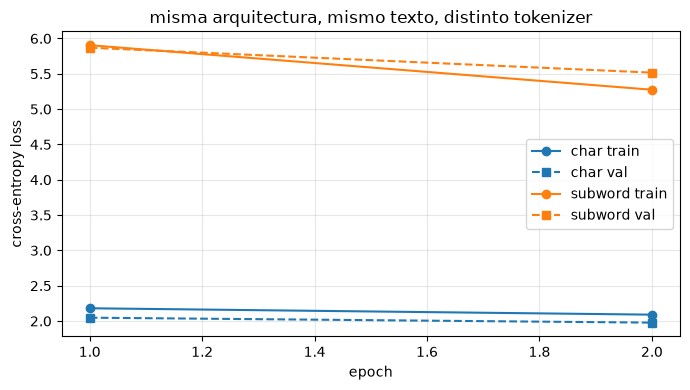


checkpoint subword -> ./checkpoints/tp1_subword/checkpoint_final.pt
El TP-2 lo carga para fine-tuning de instrucciones; el notebook de serving lo convierte a GGUF.


In [35]:
sub_model = TinyGPT(sub_config).to(device)
if device == "cuda":
    sub_model = torch.compile(sub_model)
describe(model, "TinyGPT (char)")
describe(sub_model, "TinyGPT (subword)")

sub_optimizer = make_optimizer(sub_model.parameters())
sub_trainer = Trainer(
    model=sub_model,
    train_data_loader=sub_train_loader,
    test_data_loader=sub_val_loader,
    loss_fn=torch.nn.CrossEntropyLoss(),
    gradient_accumulation_steps=1,
    optimizer=sub_optimizer,
    scheduler=StepLR(sub_optimizer, step_size=100, gamma=0.9),
    device=device,
    save_dir="./checkpoints/tp1_subword",
    save_every_n=500,
)

sub_history = run_training(sub_trainer, epochs=EPOCHS)
del sub_trainer
free()
plot_losses({"char": history, "subword": sub_history},
            title="misma arquitectura, mismo texto, distinto tokenizer")
# El TP-2 usa este checkpoint para fine-tuning de instrucciones
SUBWORD_CKPT = "./checkpoints/tp1_subword/checkpoint_final.pt"
print(f"\ncheckpoint subword -> {SUBWORD_CKPT}")
print("El TP-2 lo carga para fine-tuning de instrucciones; el notebook de serving lo convierte a GGUF.")


### NOTA

Guardá tu checkpoint en disco porque se reutiliza en el TP-II

## X.a — la métrica comparable

Implementá `bits_per_char`. Recibe una cross-entropy media en nats por token, la cantidad de
tokens del split sobre el que se midió, y la cantidad de caracteres que ese split cubre, y
devuelve bits por carácter.

Después armá la tabla de comparación: para cada modelo reportá loss de validación, bits por
token, y bits por carácter. Sólo la última columna es una comparación justa.

In [36]:
import math
def bits_per_char(loss_nats: float, n_tokens: int, n_chars: int) -> float:
    """
    Args:
        loss_nats: cross-entropy media por token, en nats (lo que devuelve CrossEntropyLoss).
        n_tokens:  cantidad de tokens del split sobre el que se midió la loss.
        n_chars:   cantidad de caracteres que cubre ese mismo split.
    """
    # nats/token -> bits totales del split -> repartidos entre los caracteres que cubre
    return loss_nats * n_tokens / (n_chars * math.log(2))


# El split de validación tiene len(data) - split tokens para el modelo de caracteres,
# y len(sub_data) - sub_split para el subword. Los dos cubren N_CHARS_VAL caracteres.
n_val_char = len(data) - split
n_val_sub = len(sub_data) - sub_split
tabla = [
    ("char denso", history["val"][-1], n_val_char),
    ("char MoE", history_moe["val"][-1], n_val_char),
    ("char DeepSeekMoE", history_ds["val"][-1], n_val_char),
    ("subword denso", sub_history["val"][-1], n_val_sub),
]
print(f"{'modelo':<17} | {'val loss (nats/tok)':>19} | {'bits/token':>10} | {'bits/char':>9}")
for name, loss, n_tok in tabla:
    print(f"{name:<17} | {loss:>19.4f} | {loss / math.log(2):>10.4f} | "
          f"{bits_per_char(loss, n_tok, N_CHARS_VAL):>9.4f}")
print(f"\ntokens/carácter: char {n_val_char / N_CHARS_VAL:.3f} | subword {n_val_sub / N_CHARS_VAL:.3f}")

modelo            | val loss (nats/tok) | bits/token | bits/char
char denso        |              1.9776 |     2.8531 |    2.8531
char MoE          |              1.8877 |     2.7233 |    2.7233
char DeepSeekMoE  |              1.8644 |     2.6898 |    2.6898
subword denso     |              5.5167 |     7.9590 |    2.4394

tokens/carácter: char 1.000 | subword 0.306


## X.b — ¿adónde se fueron los parámetros?

Los dos modelos tienen el mismo `n_embd`, `n_layer` y `n_head`, así que sus bloques
transformer son idénticos en tamaño. Todo lo demás que cambió vino del vocabulario.

Implementá `parameter_breakdown(model, vocab_size, train_ids)` reportando:

- parámetros totales,
- parámetros de embedding (`token_emb` + `head`) y su porcentaje del total,
- parámetros que no son de embedding (todo lo demás) — esto debería coincidir entre los dos
  modelos,
- cuántas filas distintas del vocabulario aparecen efectivamente en los datos de
  entrenamiento, y qué fracción del vocabulario es eso.

Corrélo para los dos modelos. El último número es el que hay que pensar más en serio.

In [37]:
def parameter_breakdown(model, vocab_size: int, train_ids, name: str = ""):
    """Separa los parámetros del modelo en embedding vs no-embedding, y reporta la cobertura del vocabulario."""
    total, _ = count_parameters(model)
    # token_emb y head comparten la matriz (tie_weights): se cuenta una sola vez.
    emb = {id(p): p for p in [*model.token_emb.parameters(), *model.head.parameters()]}
    n_emb = sum(p.numel() for p in emb.values())
    usados = len(set(train_ids))

    print(f"=== {name}")
    print(f"  parámetros totales        {total:>11,}")
    print(f"  embedding (token + head)  {n_emb:>11,}  ({100 * n_emb / total:.1f}%)")
    print(f"  no-embedding              {total - n_emb:>11,}")
    print(f"  filas del vocab usadas    {usados:>11,} de {vocab_size:,} ({100 * usados / vocab_size:.1f}%)")
    return dict(total=total, embedding=n_emb, no_embedding=total - n_emb, vocab_usado=usados)


parameter_breakdown(model, tokenizer.vocab_size, data[:split].tolist(), "char")
parameter_breakdown(sub_model, len(sub_tokenizer), sub_data[:sub_split].tolist(), "subword")

=== char
  parámetros totales            106,048
  embedding (token + head)        3,904  (3.7%)
  no-embedding                  102,144
  filas del vocab usadas             61 de 61 (100.0%)
=== subword
  parámetros totales          3,318,592
  embedding (token + head)    3,216,448  (96.9%)
  no-embedding                  102,144
  filas del vocab usadas          3,558 de 50,257 (7.1%)


{'total': 3318592,
 'embedding': 3216448,
 'no_embedding': 102144,
 'vocab_usado': 3558}

In [38]:
for name, m, tok in (("char", model, tokenizer), ("subword", sub_model, sub_tokenizer)):
    torch.manual_seed(0)
    print("=" * 70)
    print(f"### {name}")
    print(generateV2(m, tok, "To be", max_new_tokens=120, do_sample=True,
                     temperature=0.8, top_p=0.9))

### char


To bentit wars med my on arou hanoust n dirofouris, han s t s gonuchee mende the me thithere oust matede s myoundothet the la
### subword


To be,
 you,
You, must

Theen these aem you.
First Citizen:

First Citizen:
To lies,:
 This it, shall before areCOMINI have
He, and:
This they to it Coriolanus to,
The death; and.
And'd, you must, you with,

I'll that I had--
Second, and make here,
't.

SICINIUS:

MENENIUS:
IUS:
As to something, theart.




## Preguntas

1. Ordená los dos modelos por loss de validación, y después por bits por carácter. ¿Los dos
   ordenamientos coinciden? Explicá en una oración por qué la loss cruda es el eje
   equivocado, usando la relación tokens/carácter que mediste.
2. Le diste al modelo subword ~31x los parámetros y vio el mismo texto. ¿Es una comparación
   justa? Nombrá el confundidor y proponé un experimento específico que lo elimine.
3. El modelo subword corre ~430 pasos por época contra los ~1.400 del modelo de caracteres,
   sobre el mismo texto. ¿De dónde viene el ahorro, y qué costó por paso?
4. 100.000 caracteres son 61k tokens subword, repartidos en ~5.500 tipos distintos —
   aproximadamente 11 ocurrencias cada uno. El modelo de caracteres tiene 200k tokens sobre
   62 tipos. ¿Qué tokenizer esperarías que gane a esta escala de datos, y cuál a 1000x más
   datos? ¿Por qué?
5. Leé las dos muestras. Las dos son malas, pero son malas de maneras *distintas*. Describí
   la diferencia y conectala con lo que cada tokenizer hace fácil o difícil de representar.

---

**Respuestas**

| modelo | val loss (nats/token) | bits/token | bits/char |
|---|---:|---:|---:|
| char denso | 1,9776 | 2,8531 | 2,8531 |
| subword denso | 5,5167 | 7,9590 | **2,4394** |

1. **Los dos ordenamientos se invierten.** Por loss de validación gana el de caracteres (1,98 contra 5,52 nats). Por bits por carácter gana el subword (2,44 contra 2,85 bpc), y le gana también al MoE (2,72) y a DeepSeekMoE (2,69). La loss cruda es por *token*, y cada token subword cubre 1/0,306 ≈ 3,26 caracteres: hay que multiplicarla por la relación tokens/carácter (0,306) antes de comparar, y ahí el subword pasa a ganar.

2. **No es una comparación justa.** El confundidor es que **casi todos los parámetros extra son de embedding y en su mayoría están muertos.** El modelo subword tiene 3.318.592 parámetros (31,3x), pero el 96,9 % (3.216.448) son la matriz de embedding/`head`. Los no-embedding son idénticos en los dos modelos (102.144), y sólo 3.558 de las 50.257 filas del vocabulario (7,1 %) aparecen en el entrenamiento. Los 3,3M de parámetros no son "capacidad" del transformer. A eso se suma un segundo confundidor: con el mismo `block_size=32`, el subword ve ~105 caracteres de contexto y el de caracteres sólo 32.

   **Experimento que lo elimina:** entrenar un BPE propio sobre este corpus con un vocabulario chico (~512–1.000 tokens), o remapear el de GPT-2 a los 3.558 tokens usados, de manera que el embedding quede en el orden de 30–230k parámetros. Al modelo de caracteres le daría un `block_size` que cubra la misma cantidad de caracteres (~105). Después compararía bits/char con el mismo número de caracteres vistos y 3 semillas.

3. **De dónde sale el ahorro y qué costó.** El ahorro viene de la **compresión**: el mismo texto son 3,26x menos tokens, así que hay 3,26x menos ventanas de 32 tokens (430 pasos contra 1.405 por época). Lo que costó es el tamaño del vocabulario: la capa de salida pasa de 61 a 50.257 clases. Por paso, los logits son de 64 × 32 × 50.257 ≈ 103M valores (~400 MB en fp32, contra 0,5 MB), con el softmax y la cross-entropy sobre todo eso, y además el gradiente y la actualización de AdamW de 3,3M parámetros de embedding, incluidas las filas que nunca aparecen. Medido: **~1,02 s/paso contra ~31 ms/paso (≈33x)**. La época tardó 7 min 18 s contra 44 s: con 3,3x menos pasos, el entrenamiento resultó ~10x más lento.

4. **A esta escala esperaría que gane el de caracteres; a 1000x más datos, el subword.** Cada uno de los 61 caracteres aparece ~1.500 veces en entrenamiento. En nuestra corrida el subword tiene 27.580 tokens de entrenamiento sobre 3.558 tipos, unas 8 ocurrencias por tipo (el enunciado estima 11), y la mayoría de los embeddings están casi sin entrenar. Por eso esperaba que ganara el de caracteres. En la medición ganó igual el subword en bpc (2,44 contra 2,85). Atribuyo eso sobre todo a que ve ~3x más contexto en caracteres con el mismo `block_size`, y a que acierta tokens muy frecuentes y largos (nombres de personajes, `\n`, `:`) que valen varios caracteres cada uno. Igual sigue claramente subentrenado: su val loss bajó de 5,87 a 5,52 entre épocas, contra 2,05 → 1,98 del de caracteres. Con 1000x más datos (~100M caracteres) el subword gana sin discusión: cada tipo tiene miles de ocurrencias, el embedding se entrena bien y, con el mismo cómputo de atención, el contexto efectivo en caracteres es 3–4x más largo. El modelo de caracteres necesitaría secuencias 3x más largas, con atención O(T²), para ver lo mismo, y gasta capacidad en "deletrear".

5. **Son malas de maneras distintas:**
   - **Caracteres:** `To bentit wars med my on arou hanoust n dirofouris, han s t s gonuchee …`. Produce **pseudo-palabras**: secuencias de letras pronunciables, con espacios y comas en lugares razonables, pero casi ninguna palabra existe. El modelo aprendió las transiciones locales entre letras (eso es fácil cuando cada token es una letra), pero formar una palabra entera exige "recordar" 5–10 pasos seguidos de deletreo, y con 32 caracteres de contexto y este tamaño de modelo no le alcanza.
   - **Subword:** `To be,\n you,\nYou, must\n\nTheen these aem you.\nFirst Citizen:\n\nFirst Citizen: …`. **Casi todas las palabras existen** y reproduce el formato de la obra (`First Citizen:`, `SICINIUS:`, `MENENIUS:`, `Coriolanus`), pero **no hay sintaxis**: palabras en orden arbitrario, exceso de saltos de línea y puntuación (`To lies,:`). Aparecen fragmentos mal pegados (`areCOMINI`, `IUS:`, `theart`) donde el BPE parte nombres raros en varias piezas y el modelo las ensambla mal. Con el subword, la ortografía viene resuelta por el tokenizer, pero las relaciones entre 3.500 tipos con ~8 ejemplos cada uno no se aprenden con tan pocos datos.

# Conclusiones

- **La decodificación pesa tanto como el modelo.** Con los mismos pesos, greedy entra en un bucle (`the the the`), `T=1.5` produce ruido y `T=0.5` repite. La combinación `T≈0.8` + `top_p=0.9` es la más razonable, y top-p se adapta a qué tan picuda está la distribución, cosa que un `k` fijo no hace.
- **Las ventajas asintóticas no se ven en un modelo de juguete.** El KV-cache dio sólo 1,02–1,10x, porque con `block_size=32` y `n_embd=64` el tiempo es overhead por operación y no aritmética. Lo mismo vale para el MoE: las optimizaciones pensadas para GPU (batchear, rellenar por capacidad) fueron más lentas en CPU. Hay que perfilar antes de optimizar.
- **El MoE compra capacidad barata, pero el ruteo colapsa sin balanceo.** Con 2,88x los parámetros totales y 1,63x los activos, el MoE bajó la val loss de 1,978 a 1,888, a costa de 1,6–1,9x el tiempo por paso. En la capa 2 dos expertos se llevaron todos los tokens, y con DeepSeekMoE el colapso fue peor. La mejora de DeepSeekMoE (1,864) quedó dentro del ruido: a esta escala, el resultado nulo es el esperado.
- **Las métricas deben ser comparables.** Entre tokenizers distintos sólo los bits por carácter son justos. Así medido, el modelo subword (2,44 bpc) le gana a todos los de caracteres (2,69–2,85), aunque su loss cruda sea casi 3x mayor y el 97 % de sus parámetros sean embeddings, la mayoría de filas que nunca aparecen en los datos.

# ¡Felicitaciones! 🎉

Preentrenaste un GPT desde cero, implementaste las estrategias de decodificación que trae
todo LLM en producción, e implementaste cómputo condicional sparse — la única idea
arquitectónica que permite que los modelos frontier crezcan en cantidad de parámetros más
rápido que en costo de inferencia.

Lo que sigue: el TP-2, donde tomás este modelo y le enseñás a seguir instrucciones.

¡Ahora andá a alardear con tus amigos sobre cómo funcionan los LLMs y los GPTs!

